# Part 2: 예측 모델링 + 시나리오 분석

매출 예측 모델을 구축하고, 프로모션 시나리오별 영향을 분석한다.

## 목차
### 2.1 데이터 분할 및 검증 설계 (80/20 Train-Test Split)
### 2.2 시계열 피처 엔지니어링
### 2.3 예측 모델 및 성능 비교
- 2.3.1 Prophet (TimeSeriesCV)
- 2.3.2 XGBoost (Optuna 튜닝)
- 2.3.3 LightGBM (Optuna 튜닝)
- 2.3.4 CatBoost
- 2.3.5 모델 성능 비교
- 2.3.6 SHAP 분석 (모델 해석)
### 2.4 세그먼트별 예측 모델 (CatBoost)
### 2.5 프로모션 시나리오 분석 (CatBoost)
- 2.5.1 세그먼트별 프로모션 시나리오
- 2.5.2 프로모션 강도 세분화 (0~150%)
- 2.5.3 요일별 프로모션 전략
- 2.5.4 ROI 기반 최적 프로모션 수준
### 2.6 예측모델 주요 내용
### 2.7 Executive Summary
### 2.8 분석 결과 CSV 및 MD 파일 생성

In [1]:
# ============================================================================
# 라이브러리 임포트
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 모델링 라이브러리
# ============================================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score
import xgboost as xgb

# LightGBM
import lightgbm as lgb

# CatBoost
from catboost import CatBoostRegressor

# SHAP: 모델 해석 라이브러리
import shap

# Prophet: Facebook 시계열 예측 라이브러리
from prophet import Prophet

# Optuna: 하이퍼파라미터 튜닝
import optuna
from optuna.samplers import TPESampler

# ============================================================================
# 한글 폰트 설정
# ============================================================================
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

## 2.1 데이터 분할 (90/10 Train-Test Split)

시계열 데이터는 시간 순서를 유지해야 한다.

### 왜 Train/Val/Test 3분할 대신 2분할을 사용하는가?

| 분할 방식 | 장점 | 단점 |
|----------|------|------|
| 3분할 (Train/Val/Test) | 구조가 단순, 역할 분리가 명확 | Val을 따로 떼는 만큼 학습 데이터가 줄어듦 → 특히 데이터가 작으면 성능/안정성 불리 |
| **2분할 + CV** | 학습 데이터 활용 극대화, fold 평균으로 성능 추정이 안정적 | CV/파이프라인 관리가 복잡(스케일링/인코딩/피처생성 누수 방지, 시간/연산 비용 증가) |

### 이 노트북의 전략

- **Train (90%)**: 모델 학습 + Cross-Validation으로 내부 검증
- **Test (10%)**: 최종 성능 평가 (한 번만 사용)

Cross-Validation 방식:
- **Prophet**: TimeSeriesSplit (시간 순서 유지)
- **XGBoost/LightGBM/CatBoost**: K-Fold CV

In [2]:
# ============================================================================
# 데이터 로딩
# ============================================================================
DATA_PATH = './data/'

train = pd.read_csv(f'{DATA_PATH}train.csv', parse_dates=['date'])
stores = pd.read_csv(f'{DATA_PATH}stores.csv')
holidays = pd.read_csv(f'{DATA_PATH}holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(f'{DATA_PATH}transactions.csv', parse_dates=['date'])

# 일별 총 매출
daily_sales = train.groupby('date')['sales'].sum().reset_index()
daily_sales.columns = ['date', 'sales']

# cutoff 적용 (2017년 8월은 15일까지만 존재)
cutoff_date = '2017-07-31'
daily_sales = daily_sales[daily_sales['date'] <= cutoff_date]

# 1월 1일 (sales=0) 제외 - 휴무일
daily_sales = daily_sales[~((daily_sales['date'].dt.month == 1) & (daily_sales['date'].dt.day == 1))]

daily_sales.shape  # (1664, 2)


(1664, 2)

데이터 분할 결과 (90/10 Split)
Train: 2013-01-02 ~ 2017-02-14 (1497일)
Test:  2017-02-15 ~ 2017-07-31 (167일)

비율: Train 90.0% / Test 10.0%


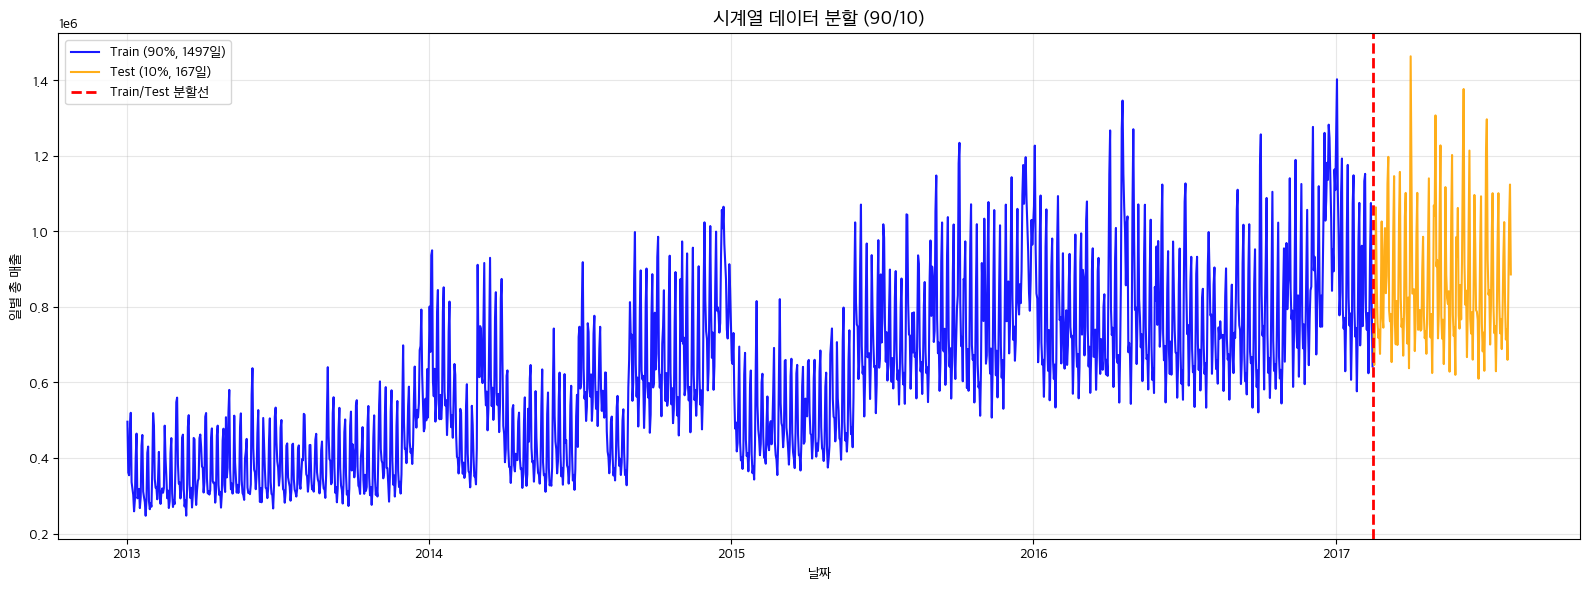

In [3]:
# ============================================================================
# 데이터 분할 (90% Train / 10% Test)
# ============================================================================
# 시계열 데이터는 시간 순서를 유지해야 함 → iloc으로 순서대로 분할
# shuffle=True 사용하면 안 됨 (미래 데이터로 과거 예측하는 문제 발생)

# 90% 지점 인덱스 계산
split_idx = int(len(daily_sales) * 0.90)

# 분할: 앞쪽 90% → 학습용, 뒤쪽 10% → 평가용
df_train = daily_sales.iloc[:split_idx].copy()
df_test = daily_sales.iloc[split_idx:].copy()

# 분할 날짜 저장 (시각화 및 다른 셀에서 사용)
train_end = df_train['date'].max()
test_start = df_test['date'].min()

# 분할 결과 확인
print("=" * 60)
print("데이터 분할 결과 (90/10 Split)")
print("=" * 60)
print(f"Train: {df_train['date'].min().strftime('%Y-%m-%d')} ~ {train_end.strftime('%Y-%m-%d')} ({len(df_train)}일)")
print(f"Test:  {test_start.strftime('%Y-%m-%d')} ~ {df_test['date'].max().strftime('%Y-%m-%d')} ({len(df_test)}일)")
print(f"\n비율: Train {len(df_train)/(len(df_train)+len(df_test))*100:.1f}% / Test {len(df_test)/(len(df_train)+len(df_test))*100:.1f}%")

# ============================================================================
# 시각화: Train/Test 분할
# ============================================================================
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df_train['date'], df_train['sales'], label=f'Train (90%, {len(df_train)}일)', color='blue', alpha=0.9)
ax.plot(df_test['date'], df_test['sales'], label=f'Test (10%, {len(df_test)}일)', color='orange', alpha=0.9)

# 분할 경계선
ax.axvline(x=train_end, color='red', linestyle='--', linewidth=2, label='Train/Test 분할선')

ax.set_title('시계열 데이터 분할 (90/10)', fontsize=14, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('일별 총 매출')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [4]:
# 평가 지표 함수 정의
from sklearn.metrics import r2_score

def evaluate_model(y_true, y_pred, model_name='Model'):
    """모델 성능 평가 함수 (실제값이 0인 경우 MAPE에서 제외)"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE: 실제값이 0인 경우 제외하여 계산
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    non_zero_mask = y_true_arr != 0
    if non_zero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true_arr[non_zero_mask] - y_pred_arr[non_zero_mask]) / y_true_arr[non_zero_mask])) * 100
    else:
        mape = np.nan
    
    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

# 결과 저장용 리스트
results = []


## 2.2 피처 엔지니어링

Part 1에서 발견한 인사이트를 바탕으로 예측 모델에 사용할 피처를 구성한다.

### 왜 미래 변수를 사용하면 안 되는가? (Data Leakage)

예측 모델의 목적은 **미래 매출을 예측**하는 것이다. 따라서 예측 시점에 알 수 없는 변수를 사용하면:

1. **학습 시**: 미래 정보를 포함하여 비정상적으로 높은 성능
2. **실제 예측 시**: 해당 변수 값을 알 수 없어 모델 사용 불가
3. **결과**: 모델이 실무에서 무용지물

```
예시: 오늘(D) 매출을 예측할 때
- type_A_ratio (당일 타입A 비중) → 오늘 매출이 끝나야 알 수 있음 → 사용 불가
- transactions (당일 거래건수) → 오늘 영업이 끝나야 알 수 있음 → 사용 불가
- lag_7 (7일 전 매출) → 이미 발생한 과거 데이터 → 사용 가능
- is_holiday (오늘이 휴일인지) → 달력으로 사전에 알 수 있음 → 사용 가능
```

### 사용 가능한 피처

| 구분 | 피처 | 예측 시점에 알 수 있나? | 이유 |
|------|------|:---------------------:|------|
| 달력 정보 | is_holiday, is_national, is_local | O | 사전 확정 |
| 시간 피처 | year, month, dayofweek, is_weekend | O | 날짜로 계산 |
| 프로모션 | total_promo | O | 사전 계획 |
| 래그 피처 | lag_1, lag_7, lag_14, lag_30 | O | 과거 값 |
| 롤링 통계 | rolling_mean_7, rolling_std_7 | O | 과거 값으로 계산 |
| 거래 래그 | trans_lag7 | O | 7일 전 값 |

### 모델별 사용 피처

| 피처 그룹 | Prophet | XGBoost/LightGBM/CatBoost |
|----------|:-------:|:-------------------------:|
| 휴일 | O | O |
| 프로모션 | O | O |
| 시간 피처 | X (내부 처리) | O |
| 래그 피처 | X | O |
| 롤링 통계 | X | O |

**Prophet**: 내부적으로 시간 의존성을 처리하므로 외부 변수는 `total_promo` + 휴일 피처만 사용
**XGBoost/LightGBM/CatBoost**: 시간 인식이 없으므로 래그/롤링 피처로 시간 의존성을 직접 학습

In [5]:
# ============================================================================
# 공통 외부 변수 생성
# ============================================================================
# 주의: 미래에 알 수 없는 변수는 제외
# - type_A_ratio, high_eff_cluster_ratio: 당일 매출 비중 → 예측 시점에 알 수 없음
# - transactions, basket_size (당일): 당일 거래 정보 → 예측 시점에 알 수 없음

train_stores = train.merge(stores[['store_nbr', 'type', 'cluster']], on='store_nbr')

# ============================================================================
# 프로모션 (사전 계획 가능 → 사용 가능)
# ============================================================================
promo_daily = train.groupby('date')['onpromotion'].sum().reset_index()
promo_daily.columns = ['date', 'total_promo']

# ============================================================================
# 휴일 피처 (달력 정보 → 사용 가능)
# ============================================================================
holiday_dates = holidays['date'].unique()
national_dates = holidays[holidays['locale'] == 'National']['date'].unique()
local_dates = holidays[holidays['locale'] == 'Local']['date'].unique()

# ============================================================================
# 거래 래그 (7일 전 값 → 사용 가능)
# ============================================================================
trans_daily = transactions.groupby('date')['transactions'].sum().reset_index()
trans_daily.columns = ['date', 'transactions']
trans_daily['trans_lag7'] = trans_daily['transactions'].shift(7)

# ============================================================================
# 외부 변수 병합
# ============================================================================
exog_common = promo_daily.copy()
exog_common = exog_common.merge(trans_daily[['date', 'trans_lag7']], on='date', how='left')

# 휴일 피처 추가
exog_common['is_holiday'] = exog_common['date'].isin(holiday_dates).astype(int)
exog_common['is_national'] = exog_common['date'].isin(national_dates).astype(int)
exog_common['is_local'] = exog_common['date'].isin(local_dates).astype(int)

exog_common = exog_common[exog_common['date'] <= cutoff_date]

# 사용 가능한 외부 변수 확인
# - total_promo: 사전 계획된 프로모션 수량
# - trans_lag7: 7일 전 거래 건수 (과거 값)
# - is_holiday, is_national, is_local: 달력 정보
exog_common.columns.tolist()


['date', 'total_promo', 'trans_lag7', 'is_holiday', 'is_national', 'is_local']

In [6]:
# 시간 피처 생성 함수

def create_time_features(df):
    """시간 기반 피처 생성"""
    df = df.copy()
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['dayofyear'] = df['date'].dt.dayofyear
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['quarter'] = df['date'].dt.quarter
    
    # 특수 일자 피처
    df['is_sunday'] = (df['dayofweek'] == 6).astype(int)
    
    return df


In [7]:
# 래그 피처 생성 함수

def create_lag_features(df, lags=[1, 7, 14, 30, 365]):
    """래그 피처 생성"""
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df['sales'].shift(lag)
    return df


In [8]:
# 롤링 통계 피처 생성 함수

def create_rolling_features(df, windows=[7, 14, 30]):
    """롤링 통계 피처 생성"""
    df = df.copy()
    for window in windows:
        df[f'rolling_mean_{window}'] = df['sales'].shift(1).rolling(window=window).mean()
        df[f'rolling_std_{window}'] = df['sales'].shift(1).rolling(window=window).std()
    
    df['ma_ratio_7_30'] = df['rolling_mean_7'] / df['rolling_mean_30']
    return df


In [9]:
# ============================================================================
# XGBoost용 피처 생성
# ============================================================================
df_features = daily_sales.copy()
df_features = create_time_features(df_features)
df_features = create_lag_features(df_features)
df_features = create_rolling_features(df_features)

# 외부 변수 병합 (total_promo, trans_lag7, 휴일 피처)
df_features = df_features.merge(exog_common, on='date', how='left')

# ============================================================================
# 미래 변수 (분석용으로 생성하나, 예측 시에는 제외)
# ============================================================================
# transactions 병합 (basket_size 계산용)
trans_daily = transactions.groupby('date')['transactions'].sum().reset_index()
trans_daily.columns = ['date', 'transactions']
df_features = df_features.merge(trans_daily, on='date', how='left')

# basket_size: 건당 매출 = 매출 / 거래건수
# (분석용으로 생성, 예측 시에는 제외해야 함)
df_features['basket_size'] = df_features['sales'] / df_features['transactions']

# 카테고리별 비중 (분석용으로 생성, 예측 시에는 제외해야 함)
family_daily = train.groupby(['date', 'family'])['sales'].sum().unstack(fill_value=0)
if 'GROCERY I' in family_daily.columns:
    grocery_ratio = (family_daily['GROCERY I'] / family_daily.sum(axis=1)).reset_index()
    grocery_ratio.columns = ['date', 'grocery_ratio']
    df_features = df_features.merge(grocery_ratio, on='date', how='left')
    
if 'PRODUCE' in family_daily.columns:
    produce_ratio = (family_daily['PRODUCE'] / family_daily.sum(axis=1)).reset_index()
    produce_ratio.columns = ['date', 'produce_ratio']
    df_features = df_features.merge(produce_ratio, on='date', how='left')

# 프로모션 래그
df_features['promo_lag1'] = df_features['total_promo'].shift(1)
df_features['promo_lag7'] = df_features['total_promo'].shift(7)

# 피처 확인
feature_cols = [c for c in df_features.columns if c not in ['date', 'sales']]
len(feature_cols)


32

## 2.3 예측 모델

### 2.3.1 Prophet (TimeSeriesCV)

Prophet은 Facebook에서 개발한 시계열 예측 라이브러리로, 트렌드/계절성/휴일 효과를 자동으로 분해한다.

**Prophet의 장점**
- 결측치, 이상치에 강건
- 연간/주간/일간 계절성 자동 분해
- 휴일 효과 직접 모델링 가능

**외부 변수 (add_regressor)**
- total_promo: 사전 계획된 프로모션
- is_holiday, is_national, is_local: 달력 정보

In [10]:
# ============================================================================
# Prophet: TimeSeriesCV
# ============================================================================

exog_cols_prophet = ['total_promo', 'is_holiday', 'is_national', 'is_local']

print("=" * 60)
print("Prophet + TimeSeriesCV")
print("=" * 60)

# 외부 변수 데이터 준비
exog_df_prophet = exog_common[['date'] + exog_cols_prophet]

# Prophet 데이터 형식 (ds, y 컬럼 필요)
prophet_train = df_train[['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})
prophet_train = prophet_train.merge(exog_df_prophet, left_on='ds', right_on='date', how='left')
prophet_train = prophet_train.drop(columns=['date']).fillna(method='ffill').fillna(0)

prophet_test = df_test[['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})
prophet_test = prophet_test.merge(exog_df_prophet, left_on='ds', right_on='date', how='left')
prophet_test = prophet_test.drop(columns=['date']).fillna(method='ffill').fillna(0)

# 휴일 데이터 (Prophet 내부용)
holidays_prophet = holidays[holidays['locale'] == 'National'][['date', 'description']].copy()
holidays_prophet.columns = ['ds', 'holiday']

# TimeSeriesCV (5-fold)
tscv = TimeSeriesSplit(n_splits=5)
cv_scores_prophet = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(prophet_train), 1):
    cv_train = prophet_train.iloc[train_idx].copy()
    cv_val = prophet_train.iloc[val_idx].copy()
    
    model_cv = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        holidays=holidays_prophet,
        changepoint_prior_scale=0.05
    )
    
    for col in exog_cols_prophet:
        model_cv.add_regressor(col)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model_cv.fit(cv_train)
    
    future_cv = cv_val[['ds'] + exog_cols_prophet].copy()
    forecast_cv = model_cv.predict(future_cv)
    
    mape_cv = mean_absolute_percentage_error(cv_val['y'], forecast_cv['yhat']) * 100
    cv_scores_prophet.append(mape_cv)
    print(f"Fold {fold}: MAPE = {mape_cv:.2f}%")

print(f"\n평균 CV MAPE: {np.mean(cv_scores_prophet):.2f}% (+/- {np.std(cv_scores_prophet):.2f}%)")

# 최종 모델 학습
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=holidays_prophet,
    changepoint_prior_scale=0.05
)

for col in exog_cols_prophet:
    model_prophet.add_regressor(col)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_prophet.fit(prophet_train)

# Test 예측
future_test = prophet_test[['ds'] + exog_cols_prophet].copy()
forecast_test = model_prophet.predict(future_test)
pred_prophet_test = forecast_test['yhat'].values

# 성능 평가
prophet_mape = mean_absolute_percentage_error(prophet_test['y'], pred_prophet_test) * 100
prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'], pred_prophet_test))

results.append({
    'model': 'Prophet',
    'CV_MAPE': np.mean(cv_scores_prophet),
    'Test_MAPE': prophet_mape,
    'RMSE': prophet_rmse,
    'R2': r2_score(prophet_test['y'], pred_prophet_test)
})

print(f"\nTest MAPE: {prophet_mape:.2f}%, R^2: {r2_score(prophet_test['y'], pred_prophet_test):.4f}")

14:04:06 - cmdstanpy - INFO - Chain [1] start processing


Prophet + TimeSeriesCV


14:04:07 - cmdstanpy - INFO - Chain [1] done processing
14:04:07 - cmdstanpy - INFO - Chain [1] start processing
14:04:07 - cmdstanpy - INFO - Chain [1] done processing
14:04:07 - cmdstanpy - INFO - Chain [1] start processing


Fold 1: MAPE = 103.61%
Fold 2: MAPE = 59.00%


14:04:07 - cmdstanpy - INFO - Chain [1] done processing
14:04:07 - cmdstanpy - INFO - Chain [1] start processing
14:04:07 - cmdstanpy - INFO - Chain [1] done processing


Fold 3: MAPE = 19.55%
Fold 4: MAPE = 23.83%


14:04:07 - cmdstanpy - INFO - Chain [1] start processing
14:04:07 - cmdstanpy - INFO - Chain [1] done processing
14:04:08 - cmdstanpy - INFO - Chain [1] start processing


Fold 5: MAPE = 17.68%

평균 CV MAPE: 44.74% (+/- 33.08%)


14:04:08 - cmdstanpy - INFO - Chain [1] done processing



Test MAPE: 9.95%, R^2: 0.4422


### 2.3.2 XGBoost (Optuna 튜닝)

XGBoost는 피처 기반으로 시간 의존성을 학습하는 트리 부스팅 모델이다.

**Optuna 튜닝 파라미터**
- n_estimators: 트리 개수 (100~500)
- max_depth: 트리 깊이 (3~10)
- learning_rate: 학습률 (0.01~0.3)
- subsample: 샘플 비율 (0.6~1.0)
- colsample_bytree: 피처 비율 (0.6~1.0)

**K-Fold vs TimeSeriesCV**
- K-Fold: 랜덤 분할 (lag 피처로 시간 정보 인코딩된 경우 유효)
- TimeSeriesCV: 시간 순서 유지

In [11]:
# ============================================================================
# XGBoost 피처 정의
# ============================================================================
# 예측 시점에 알 수 없는 변수는 반드시 제외

future_unknown_features = [
    'transactions', 'basket_size',
    'type_A_ratio', 'high_eff_cluster_ratio',
    'grocery_ratio', 'produce_ratio'
]

all_features = [col for col in df_features.columns if col not in ['date', 'sales']]
feature_cols = [f for f in all_features if f not in future_unknown_features]

df_clean = df_features.dropna()

# Train/Test 분할
train_dates = df_train['date'].values
test_dates = df_test['date'].values

train_mask = df_clean['date'].isin(train_dates)
test_mask = df_clean['date'].isin(test_dates)

X_train = df_clean[train_mask][feature_cols]
y_train = df_clean[train_mask]['sales']
X_test = df_clean[test_mask][feature_cols]
y_test = df_clean[test_mask]['sales']

print(f"Train: {len(X_train)}일, Test: {len(X_test)}일")
print(f"사용 피처 수: {len(feature_cols)}개")

Train: 1131일, Test: 167일
사용 피처 수: 28개


In [12]:
# ============================================================================
# XGBoost: Optuna 튜닝 + K-Fold
# ============================================================================

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_mapes = []
    
    for train_idx, val_idx in kf.split(X_train):
        X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_cv_train, y_cv_train, eval_set=[(X_cv_val, y_cv_val)], verbose=False)
        
        pred = model.predict(X_cv_val)
        mape = mean_absolute_percentage_error(y_cv_val, pred) * 100
        cv_mapes.append(mape)
    
    return np.mean(cv_mapes)

In [13]:
print("=" * 60)
print("XGBoost Optuna 튜닝")
print("=" * 60)

study_xgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

best_params_xgb = study_xgb.best_params
print(f"\n최적 CV MAPE: {study_xgb.best_value:.2f}%")


# 최종 모델 학습
model_xgb = xgb.XGBRegressor(**best_params_xgb, random_state=42, n_jobs=-1)
model_xgb.fit(X_train, y_train, verbose=False)

pred_xgb_test = model_xgb.predict(X_test)
xgb_mape = mean_absolute_percentage_error(y_test, pred_xgb_test) * 100

results.append({
    'model': 'XGBoost',
    'CV_MAPE': study_xgb.best_value,
    'Test_MAPE': xgb_mape,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_xgb_test)),
    'R2': r2_score(y_test, pred_xgb_test)
})

print(f"Test MAPE: {xgb_mape:.2f}%, R2: {r2_score(y_test, pred_xgb_test):.4f}")

[I 2026-03-21 14:04:08,407] A new study created in memory with name: no-name-c372d9c4-584a-4638-b34a-5ffd58366454


XGBoost Optuna 튜닝


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-21 14:04:11,900] Trial 0 finished with value: 6.776334875781505 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 6.776334875781505.
[I 2026-03-21 14:04:12,535] Trial 1 finished with value: 6.504833396520503 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.19030368381735815, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184182}. Best is trial 1 with value: 6.504833396520503.
[I 2026-03-21 14:04:13,867] Trial 2 finished with value: 7.049080697609038 and parameters: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1696753360719655, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402}. Best is trial 1 with value: 6.504833396520503.
[I 2026-03-21 14:04:14,823] Trial 3 finished with value: 6.201902910156403 and parameters: {'n_estimators': 150, 'max_depth': 5, 'learni

### 2.3.3 LightGBM (Optuna 튜닝)

LightGBM은 XGBoost보다 빠르고 메모리 효율적인 Gradient Boosting 라이브러리다.

**XGBoost vs LightGBM**
- 트리 성장 방식: XGBoost(level-wise) vs LightGBM(leaf-wise)
- LightGBM이 대용량 데이터에서 더 빠름
- 범주형 변수 직접 처리 가능 (cat_features)

In [14]:
# ============================================================================
# LightGBM: Optuna 튜닝 + K-Fold
# ============================================================================

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_mapes = []
    
    for train_idx, val_idx in kf.split(X_train):
        X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(X_cv_train, y_cv_train, eval_set=[(X_cv_val, y_cv_val)])
        
        pred = model.predict(X_cv_val)
        mape = mean_absolute_percentage_error(y_cv_val, pred) * 100
        cv_mapes.append(mape)
    
    return np.mean(cv_mapes)

In [15]:
print("=" * 60)
print("LightGBM Optuna 튜닝")
print("=" * 60)

study_lgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)

best_params_lgb = study_lgb.best_params
print(f"\n최적 CV MAPE: {study_lgb.best_value:.2f}%")


# 최종 모델 학습
model_lgb = lgb.LGBMRegressor(**best_params_lgb, random_state=42, n_jobs=-1, verbose=-1)
model_lgb.fit(X_train, y_train)

pred_lgb_test = model_lgb.predict(X_test)
lgb_mape = mean_absolute_percentage_error(y_test, pred_lgb_test) * 100

results.append({
    'model': 'LightGBM',
    'CV_MAPE': study_lgb.best_value,
    'Test_MAPE': lgb_mape,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_lgb_test)),
    'R2': r2_score(y_test, pred_lgb_test)
})

print(f"Test MAPE: {lgb_mape:.2f}%, R^2: {r2_score(y_test, pred_lgb_test):.4f}")

[I 2026-03-21 14:05:19,340] A new study created in memory with name: no-name-9f9be736-e606-48fd-b8b3-0f1c552c49c4


LightGBM Optuna 튜닝


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-21 14:05:22,882] Trial 0 finished with value: 6.251079940943464 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 6.251079940943464.
[I 2026-03-21 14:05:23,509] Trial 1 finished with value: 6.622016537001175 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.19030368381735815, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184182}. Best is trial 0 with value: 6.251079940943464.
[I 2026-03-21 14:05:25,025] Trial 2 finished with value: 6.354942917328853 and parameters: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1696753360719655, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402}. Best is trial 0 with value: 6.251079940943464.
[I 2026-03-21 14:05:26,243] Trial 3 finished with value: 6.40839505796926 and parameters: {'n_estimators': 150, 'max_depth': 5, 'learnin

### 2.3.4 CatBoost

CatBoost는 범주형 변수를 자동으로 처리하고, 기본 파라미터로도 좋은 성능을 보이는 Gradient Boosting 라이브러리다.

**CatBoost의 장점**
- 범주형 변수 자동 처리 (별도 인코딩 불필요)
- Ordered Target Encoding으로 Target Leakage 방지
- 기본 파라미터로도 우수한 성능

In [16]:
# ============================================================================
# CatBoost: 기본 파라미터
# ============================================================================
# CatBoost는 Optuna 없이도 기본값으로 좋은 성능을 보임

print("=" * 60)
print("CatBoost 모델 학습")
print("=" * 60)

# K-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_mapes_cat = []

for train_idx, val_idx in kf.split(X_train):
    X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model_cv = CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.1,
        random_seed=42,
        verbose=False
    )
    model_cv.fit(X_cv_train, y_cv_train, eval_set=(X_cv_val, y_cv_val), verbose=False)
    
    pred = model_cv.predict(X_cv_val)
    mape = mean_absolute_percentage_error(y_cv_val, pred) * 100
    cv_mapes_cat.append(mape)

print(f"CV MAPE: {np.mean(cv_mapes_cat):.2f}% (+/- {np.std(cv_mapes_cat):.2f}%)")

CatBoost 모델 학습
CV MAPE: 5.95% (+/- 0.40%)


In [17]:
# 최종 모델 학습
model_cat = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    verbose=False
)
model_cat.fit(X_train, y_train, verbose=False)

pred_cat_test = model_cat.predict(X_test)
cat_mape = mean_absolute_percentage_error(y_test, pred_cat_test) * 100

results.append({
    'model': 'CatBoost',
    'CV_MAPE': np.mean(cv_mapes_cat),
    'Test_MAPE': cat_mape,
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_cat_test)),
    'R2': r2_score(y_test, pred_cat_test)
})

print(f"Test MAPE: {cat_mape:.2f}%")
print(f"Test R²: {r2_score(y_test, pred_cat_test):.4f}")

Test MAPE: 5.98%
Test R²: 0.7676


### 2.3.5 모델 성능 비교

| 모델 | 튜닝 방법 | CV 방법 | 특징 |
|------|----------|--------|------|
| Prophet | 기본값 | TimeSeriesCV | 계절성 자동 분해 |
| XGBoost | Optuna | K-Fold | 피처 기반 학습 |
| LightGBM | Optuna | K-Fold | 빠른 학습 속도 |
| CatBoost | 기본값 | K-Fold | 범주형 자동 처리 |

모델 성능 비교


,model,CV_MAPE,Test_MAPE,RMSE,R2
1,XGBoost,6.022134,5.968628,83114.842794,0.760509
3,CatBoost,5.945014,5.984152,81867.612622,0.767643
2,LightGBM,6.151359,6.661283,88024.911733,0.731377
0,Prophet,44.736897,9.945160,126843.622145,0.442212


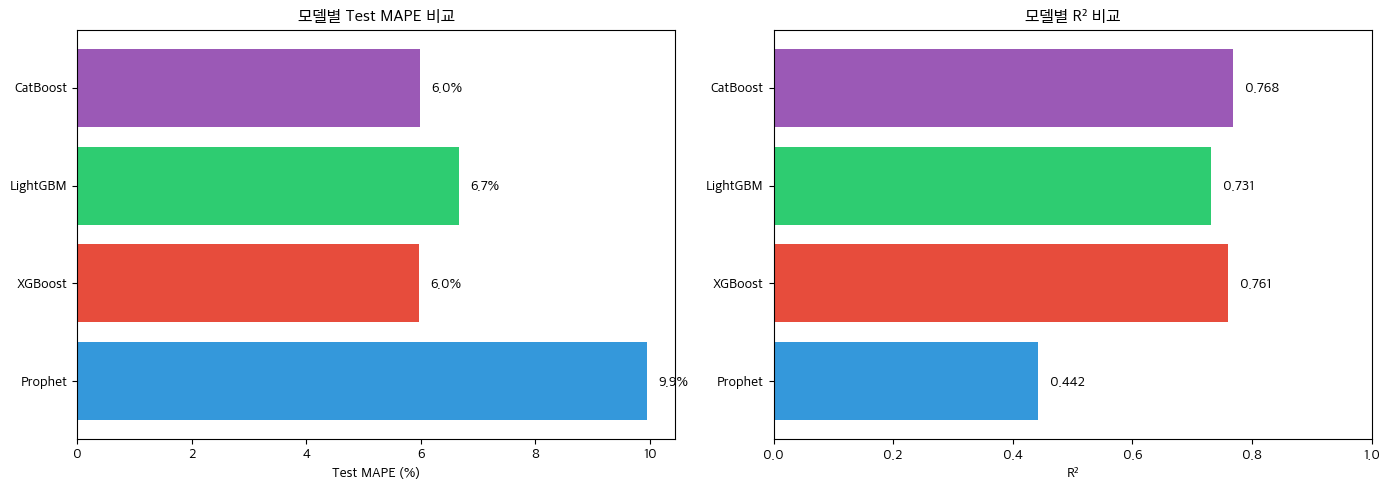


최고 성능 모델: XGBoost (Test MAPE: 5.97%, R²: 0.761)


In [18]:
# ============================================================================
# 모델 성능 비교 요약
# ============================================================================

results_df = pd.DataFrame(results)

print("=" * 70)
print("모델 성능 비교")
print("=" * 70)
display(results_df.sort_values('Test_MAPE'))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results_df['model'].values
test_mapes = results_df['Test_MAPE'].values
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

axes[0].barh(models, test_mapes, color=colors)
axes[0].set_xlabel('Test MAPE (%)')
axes[0].set_title('모델별 Test MAPE 비교', fontsize=12, fontweight='bold')
for i, v in enumerate(test_mapes):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center')

r2_scores = results_df['R2'].values
axes[1].barh(models, r2_scores, color=colors)
axes[1].set_xlabel('R²')
axes[1].set_title('모델별 R² 비교', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 1)
for i, v in enumerate(r2_scores):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

best_model = results_df.loc[results_df['Test_MAPE'].idxmin(), 'model']
best_mape = results_df['Test_MAPE'].min()
best_r2 = results_df.loc[results_df['Test_MAPE'].idxmin(), 'R2']
print(f"\n최고 성능 모델: {best_model} (Test MAPE: {best_mape:.2f}%, R²: {best_r2:.3f})")

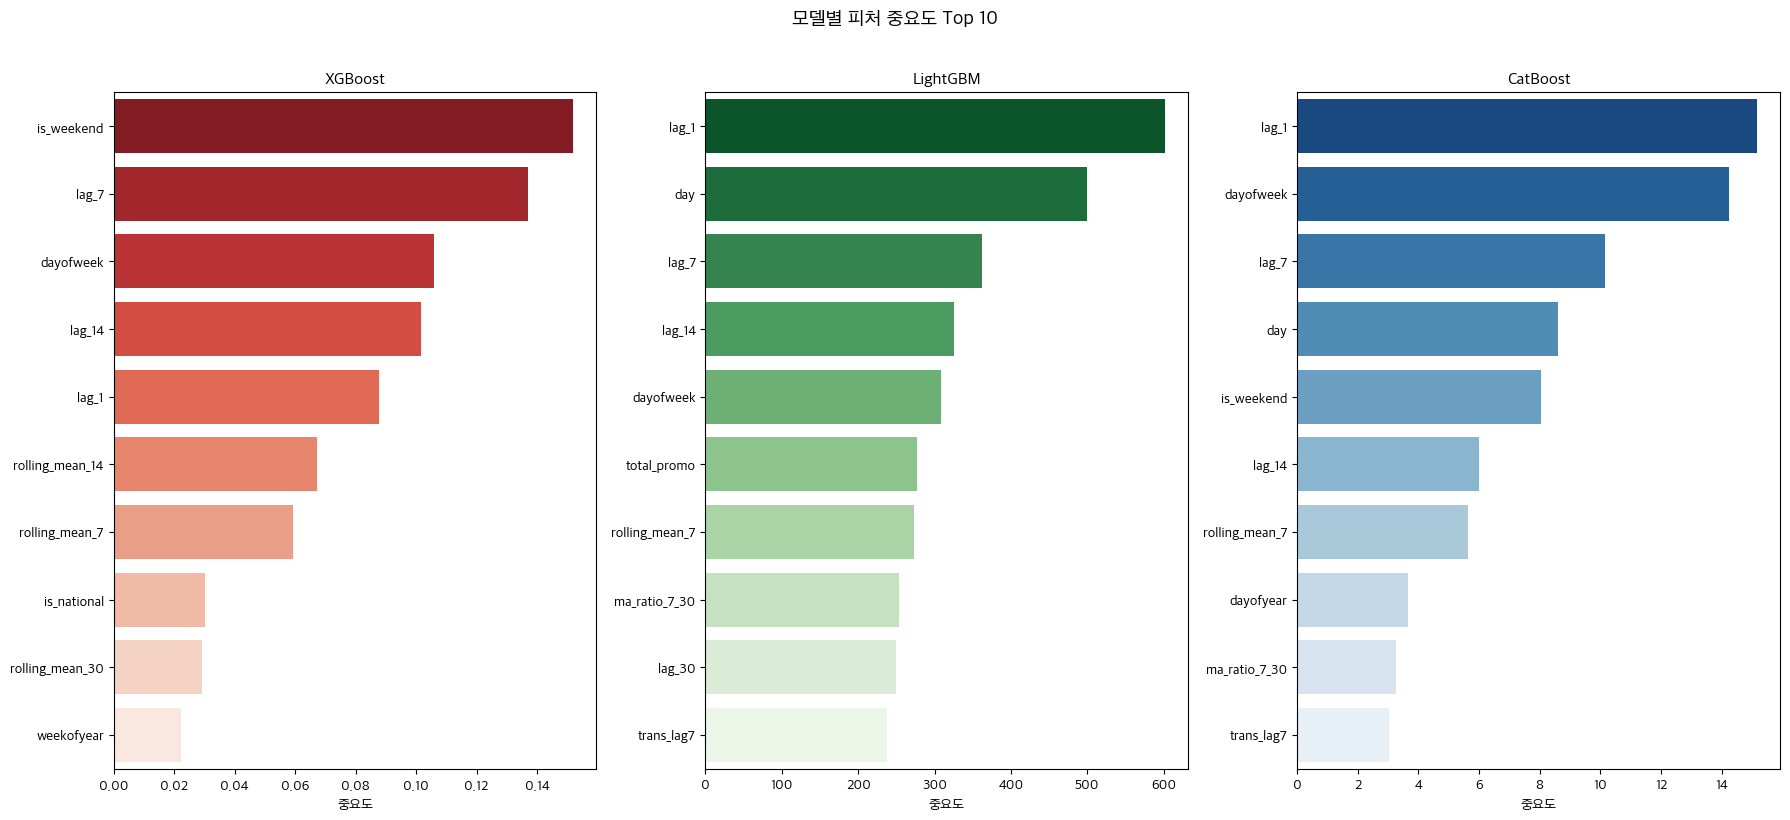

3개 모델 공통 Top 5 피처: {'lag_1', 'dayofweek', 'lag_7'}


In [19]:
# ============================================================================
# 피처 중요도 비교 (XGBoost, LightGBM, CatBoost)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# XGBoost 피처 중요도
fi_xgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(data=fi_xgb.head(10), x='importance', y='feature', ax=axes[0], palette='Reds_r')
axes[0].set_title('XGBoost', fontsize=12, fontweight='bold')
axes[0].set_xlabel('중요도')
axes[0].set_ylabel('')

# LightGBM 피처 중요도
fi_lgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_lgb.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(data=fi_lgb.head(10), x='importance', y='feature', ax=axes[1], palette='Greens_r')
axes[1].set_title('LightGBM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('중요도')
axes[1].set_ylabel('')

# CatBoost 피처 중요도
fi_cat = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_cat.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(data=fi_cat.head(10), x='importance', y='feature', ax=axes[2], palette='Blues_r')
axes[2].set_title('CatBoost', fontsize=12, fontweight='bold')
axes[2].set_xlabel('중요도')
axes[2].set_ylabel('')

plt.suptitle('모델별 피처 중요도 Top 10', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3개 모델 공통 Top 5 피처 확인
top5_xgb = set(fi_xgb.head(5)['feature'])
top5_lgb = set(fi_lgb.head(5)['feature'])
top5_cat = set(fi_cat.head(5)['feature'])
common_top5 = top5_xgb & top5_lgb & top5_cat

print(f"3개 모델 공통 Top 5 피처: {common_top5}")

### 2.3.6 SHAP 분석 (모델 해석)

SHAP (SHapley Additive exPlanations)은 게임 이론의 Shapley Value를 머신러닝에 적용한 기법

**기존 Feature Importance vs SHAP**

| 방법 | 원리 | 장점 | 단점 |
|------|-----|------|------|
| Gain-based | 분할 시 정보이득 합산 | 빠른 계산 | 상관 피처에 편향 |
| Permutation | 피처 셔플 후 성능 하락 측정 | 모델 비의존 | 상관 피처에 민감 |
| **SHAP** | 모든 피처 조합에서 기여도 계산 | 이론적으로 정확 | 계산 비용 높음 |

**SHAP Summary Plot 해석**
- X축: SHAP Value (예측에 대한 기여도)
- Y축: 피처 (중요도 순)
- 색상: 피처 값 (빨강=높음, 파랑=낮음)

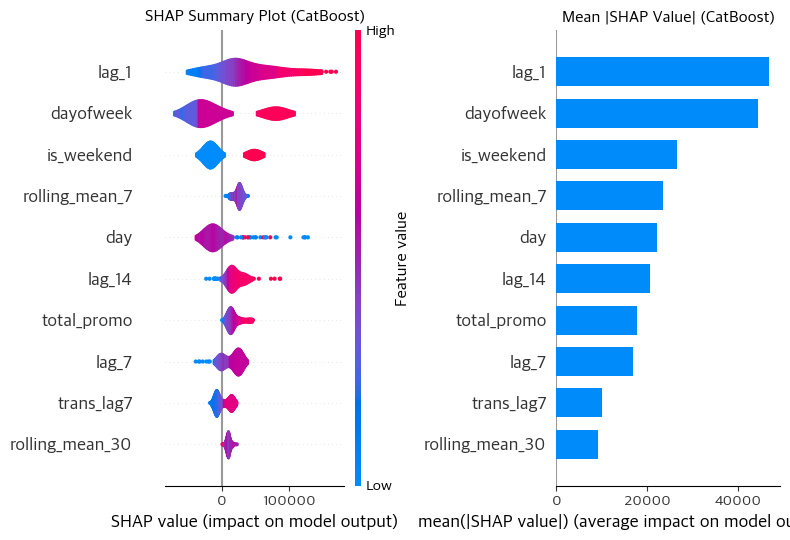


[SHAP vs Gain-based 피처 중요도 비교]
SHAP Top 5                | Gain Top 5               
--------------------------------------------------
lag_1                     | lag_1                    
dayofweek                 | dayofweek                
is_weekend                | lag_7                    
rolling_mean_7            | day                      
day                       | is_weekend               
lag_14                    | lag_14                   
total_promo               | rolling_mean_7           
lag_7                     | dayofyear                
trans_lag7                | ma_ratio_7_30            
rolling_mean_30           | trans_lag7               


In [20]:
# ============================================================================
# SHAP 분석: CatBoost 모델 해석 (최고 성능 모델)
# ============================================================================
# SHAP은 계산 비용이 높으므로 CatBoost만 분석

# TreeExplainer: 트리 기반 모델에 최적화된 SHAP 계산기
explainer = shap.TreeExplainer(model_cat)

# Test 데이터에 대한 SHAP Value 계산
# shap_values: 각 샘플 x 각 피처의 기여도 행렬
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------
# 왼쪽: Summary Plot (Beeswarm)
# -------------------------------------------------------------------
# 각 점 = 하나의 샘플
# X축 위치 = 해당 샘플에서 그 피처의 SHAP Value
# 색상 = 해당 샘플의 피처 실제 값
plt.subplot(1, 2, 1)
shap.summary_plot(shap_values, X_test, plot_type='violin', show=False, max_display=10)
plt.title('SHAP Summary Plot (CatBoost)', fontsize=12)

# -------------------------------------------------------------------
# 오른쪽: Bar Plot (평균 절대 SHAP Value)
# -------------------------------------------------------------------
# mean(|SHAP|): 피처의 전체적인 영향력 크기
plt.subplot(1, 2, 2)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=10)
plt.title('Mean |SHAP Value| (CatBoost)', fontsize=12)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# SHAP vs Gain-based 비교
# -------------------------------------------------------------------
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

# CatBoost 기본 feature importance와 비교
cat_importance = pd.DataFrame({
    'feature': feature_cols,
    'gain_importance': model_cat.feature_importances_
}).sort_values('gain_importance', ascending=False)

comparison = shap_importance.head(10).merge(
    cat_importance.head(10), on='feature', how='outer'
).fillna(0)

# SHAP과 Gain 순위 비교
# 결과가 유사하면 모델이 안정적으로 학습됨
# 결과가 다르면 피처 간 상관관계 영향 가능성
print('\n[SHAP vs Gain-based 피처 중요도 비교]')
print('=' * 50)
print(f'{"SHAP Top 5":<25} | {"Gain Top 5":<25}')
print('-' * 50)
for i in range(10):
    shap_feat = shap_importance.iloc[i]['feature'] if i < len(shap_importance) else '-'
    gain_feat = cat_importance.iloc[i]['feature'] if i < len(cat_importance) else '-'
    print(f'{shap_feat:<25} | {gain_feat:<25}')

## 2.4 세그먼트별 예측 모델

전체 매출 예측보다 세그먼트별 예측이 실제 사업 전략 수립에 더 유용하다.

**사용 모델: CatBoost** (Test MAPE 기준 최고 성능)

| 세그먼트 | 특징 | 비즈니스 의미 |
|---------|------|--------------|
| Quito + Type A | 수도 + 대형 매장 | 매출 핵심, 성장 전략 타겟 |
| Quito + Type D | 수도 + 소형 매장 | 효율성 전략 타겟 |

### 2.4.1 세그먼트 데이터 준비

In [21]:
# 카테고리 비중 계산
train_segment = train.merge(stores, on='store_nbr')

family_daily_seg = train.groupby(['date', 'family'])['sales'].sum().unstack(fill_value=0)
daily_total_seg = family_daily_seg.sum(axis=1)

grocery_ratio_seg = (family_daily_seg['GROCERY I'] / daily_total_seg).reset_index()
grocery_ratio_seg.columns = ['date', 'grocery_ratio']
grocery_ratio_seg['date'] = pd.to_datetime(grocery_ratio_seg['date'])

produce_ratio_seg = (family_daily_seg['PRODUCE'] / daily_total_seg).reset_index()
produce_ratio_seg.columns = ['date', 'produce_ratio']
produce_ratio_seg['date'] = pd.to_datetime(produce_ratio_seg['date'])


In [22]:
# Quito + Type A 데이터 (대형 매장)
quito_a = train_segment[(train_segment['city'] == 'Quito') & (train_segment['type'] == 'A')]
daily_quito_a = quito_a.groupby('date').agg({'sales': 'sum', 'onpromotion': 'sum'}).reset_index()
daily_quito_a.columns = ['date', 'sales', 'total_promo']
daily_quito_a['date'] = pd.to_datetime(daily_quito_a['date'])

# 카테고리 비중 병합
daily_quito_a = daily_quito_a.merge(grocery_ratio_seg, on='date', how='left')
daily_quito_a = daily_quito_a.merge(produce_ratio_seg, on='date', how='left')
daily_quito_a = daily_quito_a[daily_quito_a['date'] <= cutoff_date]
daily_quito_a = daily_quito_a[~((daily_quito_a['date'].dt.month == 1) & (daily_quito_a['date'].dt.day == 1))]

print(f"Quito+A 데이터: {len(daily_quito_a)}건")


Quito+A 데이터: 1664건


In [23]:
# Quito + Type D 데이터 (소형 매장)
quito_d = train_segment[(train_segment['city'] == 'Quito') & (train_segment['type'] == 'D')]
daily_quito_d = quito_d.groupby('date').agg({'sales': 'sum', 'onpromotion': 'sum'}).reset_index()
daily_quito_d.columns = ['date', 'sales', 'total_promo']
daily_quito_d['date'] = pd.to_datetime(daily_quito_d['date'])

# 카테고리 비중 병합
daily_quito_d = daily_quito_d.merge(grocery_ratio_seg, on='date', how='left')
daily_quito_d = daily_quito_d.merge(produce_ratio_seg, on='date', how='left')
daily_quito_d = daily_quito_d[daily_quito_d['date'] <= cutoff_date]
daily_quito_d = daily_quito_d[~((daily_quito_d['date'].dt.month == 1) & (daily_quito_d['date'].dt.day == 1))]


print(f"Quito+D 데이터: {len(daily_quito_d)}건")

# 세그먼트 매출 비중 확인
total_sales = daily_sales['sales'].sum()
quito_a_ratio = daily_quito_a['sales'].sum() / total_sales * 100
quito_d_ratio = daily_quito_d['sales'].sum() / total_sales * 100

print(f"세그먼트별 매출 비중:")
print(f"  Quito+A (대형): {quito_a_ratio:.1f}%")
print(f"  Quito+D (소형): {quito_d_ratio:.1f}%")


Quito+D 데이터: 1664건
세그먼트별 매출 비중:
  Quito+A (대형): 26.9%
  Quito+D (소형): 17.5%


### 2.4.2 Quito + Type A 모델 (대형 매장)


In [24]:
# ============================================================================
# 세그먼트 모델 구축 함수 (80/20 분할 + CatBoost)
# ============================================================================
# CatBoost가 Test MAPE 기준 최고 성능을 보였으므로 세그먼트 모델에도 적용

def build_segment_model(segment_daily, segment_name):
    """세그먼트별 CatBoost 모델 구축 (90/10 분할 + CV)"""
    
    # Step 1: 피처 생성
    df_seg = segment_daily.copy()
    df_seg['date'] = pd.to_datetime(df_seg['date'])
    df_seg = create_time_features(df_seg)
    df_seg = create_lag_features(df_seg)
    df_seg = create_rolling_features(df_seg)
    
    if 'total_promo' in df_seg.columns:
        df_seg['promo_lag1'] = df_seg['total_promo'].shift(1)
        df_seg['promo_lag7'] = df_seg['total_promo'].shift(7)
    
    feature_cols_seg = [c for c in df_seg.columns if c not in ['date', 'sales']]
    df_seg_clean = df_seg.dropna()
    
    # Step 2: 90/10 데이터 분할
    split_idx = int(len(df_seg_clean) * 0.9)
    train_data = df_seg_clean.iloc[:split_idx]
    test_data = df_seg_clean.iloc[split_idx:]
    
    X_train_seg = train_data[feature_cols_seg]
    y_train_seg = train_data['sales']
    X_test_seg = test_data[feature_cols_seg]
    y_test_seg = test_data['sales']
    
    # Step 3: K-Fold CV
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_mapes = []
    
    for train_idx, val_idx in kf.split(X_train_seg):
        X_cv_train, X_cv_val = X_train_seg.iloc[train_idx], X_train_seg.iloc[val_idx]
        y_cv_train, y_cv_val = y_train_seg.iloc[train_idx], y_train_seg.iloc[val_idx]
        
        model_cv = CatBoostRegressor(
            iterations=500, depth=6, learning_rate=0.1,
            random_seed=42, verbose=False
        )
        model_cv.fit(X_cv_train, y_cv_train, eval_set=(X_cv_val, y_cv_val), verbose=False)
        
        pred_cv = model_cv.predict(X_cv_val)
        mape_cv = mean_absolute_percentage_error(y_cv_val, pred_cv) * 100
        cv_mapes.append(mape_cv)
    
    cv_result = {
        'model': f'{segment_name}',
        'CV_MAPE': np.mean(cv_mapes),
        'CV_std': np.std(cv_mapes)
    }
    
    # Step 4: 최종 모델 학습
    model_seg = CatBoostRegressor(
        iterations=500, depth=6, learning_rate=0.1,
        random_seed=42, verbose=False
    )
    model_seg.fit(X_train_seg, y_train_seg, verbose=False)
    
    pred_test_seg = model_seg.predict(X_test_seg)
    result_test = evaluate_model(y_test_seg.values, pred_test_seg, f'{segment_name}')
    
    print(f"[{segment_name}] CV MAPE: {np.mean(cv_mapes):.2f}% | Test MAPE: {result_test['MAPE']:.2f}% | R2: {result_test['R2']:.4f}")
    
    return {
        'model': model_seg,
        'cv_result': cv_result,
        'result_test': result_test,
        'y_test': y_test_seg,
        'pred_test': pred_test_seg,
        'dates_test': test_data['date'],
        'feature_cols': feature_cols_seg,
        'df_clean': df_seg_clean
    }


In [25]:
# ============================================================================
# Quito+A 모델 학습 및 평가
# ============================================================================
# Quito(수도) + Type A(대형 매장) 세그먼트
# 매출 비중 약 26.9% → 핵심 성장 전략 타겟

quito_a_result = build_segment_model(daily_quito_a, 'Quito+A')


[Quito+A] CV MAPE: 7.41% | Test MAPE: 6.66% | R2: 0.8345


### 2.4.3 Quito + Type D 모델 (소형 매장)


In [26]:
# ============================================================================
# Quito+D 모델 학습 및 평가
# ============================================================================
# Quito(수도) + Type D(소형 매장) 세그먼트
# 매출 비중 약 17.5% → 효율화 전략 타겟

quito_d_result = build_segment_model(daily_quito_d, 'Quito+D')


[Quito+D] CV MAPE: 6.12% | Test MAPE: 6.18% | R2: 0.7221


### 2.4.4 세그먼트별 성능 비교


In [27]:
# ============================================================================
# 세그먼트별 성능 비교
# ============================================================================
# 전체 모델 vs 세그먼트별 모델 성능 비교
# 세그먼트별 모델이 더 좋으면 → 타겟팅 전략 효과적

# Test 성능 비교
segment_comparison = pd.DataFrame([
    {'세그먼트': '전체 매출', 
     'CV_MAPE': results_df[results_df['model'] == 'XGBoost']['CV_MAPE (K-Fold)'].values[0] if 'CV_MAPE (K-Fold)' in results_df.columns else np.nan,
     'Test_MAPE': results_df[results_df['model'] == 'XGBoost']['Test_MAPE'].values[0] if 'Test_MAPE' in results_df.columns else results_df[results_df['model'] == 'XGBoost']['MAPE'].values[0],
     'R2': results_df[results_df['model'] == 'XGBoost']['R2'].values[0],
     '매출 비중': 100.0},
    {'세그먼트': 'Quito+A', 
     'CV_MAPE': quito_a_result['cv_result']['CV_MAPE'],
     'Test_MAPE': quito_a_result['result_test']['MAPE'],
     'R2': quito_a_result['result_test']['R2'],
     '매출 비중': quito_a_ratio},
    {'세그먼트': 'Quito+D', 
     'CV_MAPE': quito_d_result['cv_result']['CV_MAPE'],
     'Test_MAPE': quito_d_result['result_test']['MAPE'],
     'R2': quito_d_result['result_test']['R2'],
     '매출 비중': quito_d_ratio}
])

print("=" * 70)
print("세그먼트별 모델 성능 비교")
print("=" * 70)
display(segment_comparison)



세그먼트별 모델 성능 비교


,세그먼트,CV_MAPE,Test_MAPE,R2,매출 비중
0,전체 매출,NaN,5.968628,0.760509,100.000000
1,Quito+A,7.406715,6.661031,0.834501,26.928167
2,Quito+D,6.122170,6.178926,0.722089,17.517607


### 세그먼트별 예측 성능 해석

| 세그먼트 | CV MAPE | Test MAPE | R² | 매출 비중 |
|---------|---------|-----------|-----|---------|
| 전체 매출 | - | 5.97% | 0.76 | 100% |
| Quito+A | 7.41% | 6.66% | 0.83 | 27% |
| Quito+D | 6.12% | 6.18% | 0.72 | 17.5% |

---

**1. 예측 정확도 (MAPE)**
- 전체/세그먼트 모두 MAPE 6~7% 수준으로 양호
- 세그먼트별 분리해도 예측 정확도 유지

**2. CV vs Test 비교**
- Quito+A: CV 7.41% → Test 6.66% → 과적합 없음
- Quito+D: CV 6.12% → Test 6.18% → 안정적
- 두 세그먼트 모두 일반화 성능 양호

**3. R² (분산 설명력)**
- Quito+A: 83% → 대형 매장 매출 패턴이 일관적
- Quito+D: 72% → 소형 매장은 상대적으로 변동성 있음
- 전체: 76% → 평균적인 설명력

**4. CV_MAPE가 NaN인 이유**
- 전체 매출은 3.3절 model_cat의 Test 결과 사용
- 세그먼트는 build_segment_model에서 K-Fold CV 별도 수행

---

**비즈니스 활용**

| 세그먼트 | 예측 신뢰도 | 활용 |
|---------|-----------|------|
| 전체 | 높음 | 전사 매출 예측 |
| Quito+A | 높음 | 대형 매장 프로모션 시뮬레이션 |
| Quito+D | 양호 | 소형 매장 효율화 전략 |

## 2.5 프로모션 시나리오 분석

프로모션 수준에 따른 매출 변화를 예측합니다.


프로모션 관련 피처: ['total_promo', 'promo_lag1', 'promo_lag7']


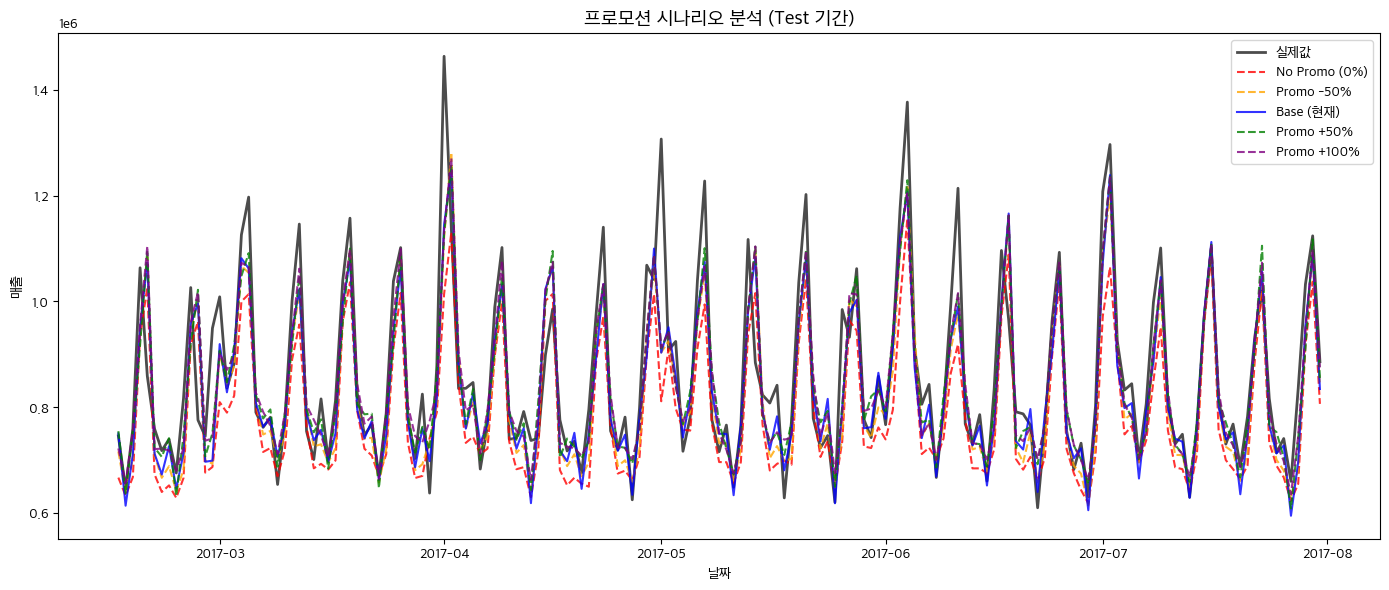


프로모션 시나리오별 예측 영향:
  No Promo (0%): 789,034 (-5.16%)
  Promo -50%: 822,232 (-1.17%)
  Base (현재): 831,980 (+0.00%)
  Promo +50%: 841,943 (+1.20%)
  Promo +100%: 844,150 (+1.46%)


In [28]:
# 프로모션 시나리오 분석 (Test 기간)

# 프로모션 관련 피처 식별
promo_cols = [col for col in X_test.columns if 'promo' in col.lower()]
print(f"프로모션 관련 피처: {promo_cols}")

# 시나리오 정의 (5가지)
scenarios = {
    'No Promo (0%)': 0,
    'Promo -50%': 0.5,
    'Base (현재)': 1,
    'Promo +50%': 1.5,
    'Promo +100%': 2.0
}

# 시나리오별 예측 (Test 데이터 기준)
scenario_results = {}
for name, multiplier in scenarios.items():
    X_scenario = X_test.copy()
    for col in promo_cols:
        X_scenario[col] = X_scenario[col] * multiplier
    pred = model_cat.predict(X_scenario)
    scenario_results[name] = pred

# 시각화
fig, ax = plt.subplots(figsize=(14, 6))

test_dates_sc = df_clean[test_mask]['date'].values
colors = ['red', 'orange', 'blue', 'green', 'purple']

ax.plot(test_dates_sc, y_test, label='실제값', color='black', linewidth=2, alpha=0.7)

for (name, pred), color in zip(scenario_results.items(), colors):
    ax.plot(test_dates_sc, pred, label=name, color=color, linestyle='--' if name != 'Base (현재)' else '-', alpha=0.8)

ax.set_title('프로모션 시나리오 분석 (Test 기간)', fontsize=14, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('매출')
ax.legend()

plt.tight_layout()
plt.show()

# 시나리오별 영향 요약
print(f"\n프로모션 시나리오별 예측 영향:")
base_mean = scenario_results['Base (현재)'].mean()
for name, pred in scenario_results.items():
    change = (pred.mean() / base_mean - 1) * 100
    print(f"  {name}: {pred.mean():,.0f} ({change:+.2f}%)")


### 2.5.1 세그먼트별 프로모션 시나리오

세그먼트별 프로모션 효과를 분석합니다.

| 세그먼트 | 전략적 의미 | 시나리오 분석 목적 |
|---------|------------|-----------------|
| Quito+A | 매출 핵심 (대형 매장) | 프로모션 투자 결정 |
| Quito+D | 효율성 타겟 (소형 매장) | 프로모션 효율화 |


In [29]:
# ============================================================================
# 세그먼트별 프로모션 시나리오 분석 함수
# ============================================================================
# 80/20 분할 기준으로 Test 데이터에서 시나리오 분석

def segment_promo_scenario(model, df_features, train_end_date):
    """세그먼트별 프로모션 시나리오 분석 (Test 기간)"""
    feature_cols_seg = [c for c in df_features.columns if c not in ['date', 'sales']]
    df_clean = df_features.dropna()
    
    # 80/20 분할 기준으로 Test 데이터 추출
    train_end_dt = pd.to_datetime(train_end_date)
    test_mask = df_clean['date'] > train_end_dt
    
    X_test_seg = df_clean[test_mask][feature_cols_seg]
    y_test_seg = df_clean[test_mask]['sales']
    test_dates = df_clean[test_mask]['date'].values
    promo_cols = [col for col in X_test_seg.columns if 'promo' in col.lower()]
    
    # 시나리오 정의 (Cell 36과 동일한 키 이름 사용)
    scenarios = {
        'No Promo (0%)': None,
        'Promo -50%': None,
        'Base (현재)': model.predict(X_test_seg),
        'Promo +50%': None,
        'Promo +100%': None
    }
    
    # 각 시나리오별 예측
    multipliers = {'No Promo (0%)': 0, 'Promo -50%': 0.5, 'Promo +50%': 1.5, 'Promo +100%': 2.0}
    
    for name, mult in multipliers.items():
        X_scenario = X_test_seg.copy()
        for col in promo_cols:
            X_scenario[col] = X_scenario[col] * mult
        scenarios[name] = model.predict(X_scenario)
    
    return scenarios, y_test_seg, test_dates


In [30]:
# ============================================================================
# 세그먼트별 피처 준비 및 시나리오 실행
# ============================================================================
# train_end: Cell 4에서 정의된 80/20 분할 기준점

# Quito+A 피처 준비
df_quito_a = daily_quito_a.copy()
df_quito_a['date'] = pd.to_datetime(df_quito_a['date'])
df_quito_a = create_time_features(df_quito_a)
df_quito_a = create_lag_features(df_quito_a)
df_quito_a = create_rolling_features(df_quito_a)
if 'total_promo' in df_quito_a.columns:
    df_quito_a['promo_lag1'] = df_quito_a['total_promo'].shift(1)
    df_quito_a['promo_lag7'] = df_quito_a['total_promo'].shift(7)

# Quito+A 시나리오 분석
scenario_quito_a, y_test_quito_a_sc, dates_quito_a_sc = segment_promo_scenario(
    quito_a_result['model'], df_quito_a, train_end)

# Quito+D 피처 준비
df_quito_d = daily_quito_d.copy()
df_quito_d['date'] = pd.to_datetime(df_quito_d['date'])
df_quito_d = create_time_features(df_quito_d)
df_quito_d = create_lag_features(df_quito_d)
df_quito_d = create_rolling_features(df_quito_d)
if 'total_promo' in df_quito_d.columns:
    df_quito_d['promo_lag1'] = df_quito_d['total_promo'].shift(1)
    df_quito_d['promo_lag7'] = df_quito_d['total_promo'].shift(7)

# Quito+D 시나리오 분석
scenario_quito_d, y_test_quito_d_sc, dates_quito_d_sc = segment_promo_scenario(
    quito_d_result['model'], df_quito_d, train_end)

print("시나리오 분석 완료: Quito+A, Quito+D")


시나리오 분석 완료: Quito+A, Quito+D


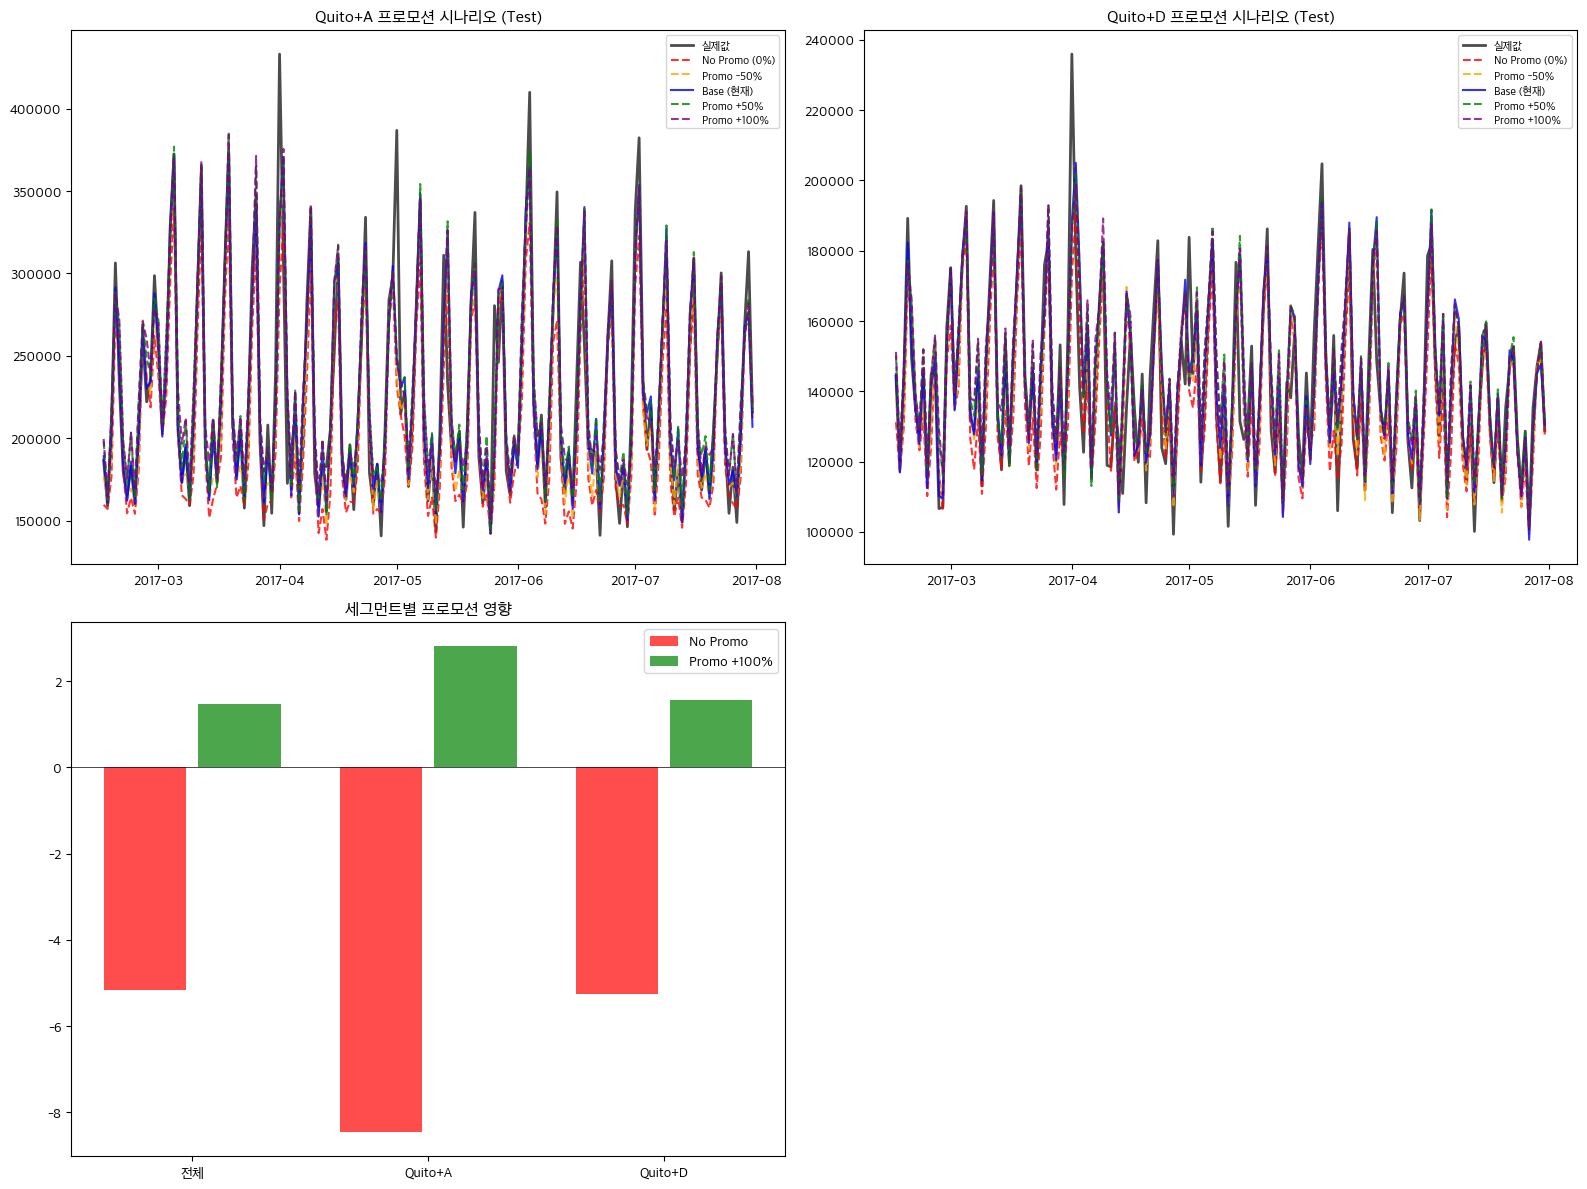

In [31]:
# 세그먼트별 시나리오 시각화 (Test 기간)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ['red', 'orange', 'blue', 'green', 'purple']

# Quito+A 시나리오
axes[0, 0].plot(dates_quito_a_sc, y_test_quito_a_sc, label='실제값', color='black', linewidth=2, alpha=0.7)
for (name, pred), color in zip(scenario_quito_a.items(), colors):
    axes[0, 0].plot(dates_quito_a_sc, pred, label=name, color=color, 
                    linestyle='--' if name != 'Base (현재)' else '-', alpha=0.8)
axes[0, 0].set_title('Quito+A 프로모션 시나리오 (Test)')
axes[0, 0].legend(fontsize=8)

# Quito+D 시나리오
axes[0, 1].plot(dates_quito_d_sc, y_test_quito_d_sc, label='실제값', color='black', linewidth=2, alpha=0.7)
for (name, pred), color in zip(scenario_quito_d.items(), colors):
    axes[0, 1].plot(dates_quito_d_sc, pred, label=name, color=color, 
                    linestyle='--' if name != 'Base (현재)' else '-', alpha=0.8)
axes[0, 1].set_title('Quito+D 프로모션 시나리오 (Test)')
axes[0, 1].legend(fontsize=8)

# 프로모션 영향 비교
segment_impact = []
for seg_name, sc_res in [('전체', scenario_results), ('Quito+A', scenario_quito_a), ('Quito+D', scenario_quito_d)]:
    base = sc_res['Base (현재)'].mean()
    segment_impact.append({
        '세그먼트': seg_name, 
        'No Promo': (sc_res['No Promo (0%)'].mean() / base - 1) * 100, 
        'Promo +100%': (sc_res['Promo +100%'].mean() / base - 1) * 100
    })
impact_df = pd.DataFrame(segment_impact)

x = np.arange(len(impact_df))
axes[1, 0].bar(x - 0.2, impact_df['No Promo'], 0.35, label='No Promo', color='red', alpha=0.7)
axes[1, 0].bar(x + 0.2, impact_df['Promo +100%'], 0.35, label='Promo +100%', color='green', alpha=0.7)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(impact_df['세그먼트'])
axes[1, 0].set_title('세그먼트별 프로모션 영향')
axes[1, 0].legend()
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

axes[1, 1].axis('off')
plt.tight_layout()
plt.show()


In [32]:
# 시나리오 결과 요약 (Test 기간)
# print("세그먼트별 프로모션 시나리오 요약 (Test 기간):")

for seg_name, sc_res in [('전체 매출', scenario_results), ('Quito+A', scenario_quito_a), ('Quito+D', scenario_quito_d)]:
    base = sc_res['Base (현재)'].mean()
    print(f"\n  [{seg_name}]")
    for name, pred in sc_res.items():
        change = (pred.mean() / base - 1) * 100
        print(f"    {name}: {pred.mean():,.0f} ({change:+.2f}%)")



  [전체 매출]
    No Promo (0%): 789,034 (-5.16%)
    Promo -50%: 822,232 (-1.17%)
    Base (현재): 831,980 (+0.00%)
    Promo +50%: 841,943 (+1.20%)
    Promo +100%: 844,150 (+1.46%)

  [Quito+A]
    No Promo (0%): 205,194 (-8.45%)
    Promo -50%: 216,842 (-3.26%)
    Base (현재): 224,138 (+0.00%)
    Promo +50%: 229,454 (+2.37%)
    Promo +100%: 230,427 (+2.81%)

  [Quito+D]
    No Promo (0%): 135,778 (-5.25%)
    Promo -50%: 140,505 (-1.95%)
    Base (현재): 143,302 (+0.00%)
    Promo +50%: 145,303 (+1.40%)
    Promo +100%: 145,539 (+1.56%)


### 프로모션 시나리오 해석

| 시나리오 | 전체 매출 | Quito+A | Quito+D |
|---------|----------|---------|---------|
| No Promo (0%) | -5.16% | -8.45% | -5.25% |
| Promo -50% | -1.17% | -3.26% | -1.95% |
| Base (현재) | 0% | 0% | 0% |
| Promo +50% | +1.20% | +2.37% | +1.40% |
| Promo +100% | +1.46% | +2.81% | +1.56% |

---

**1. 세그먼트별 프로모션 민감도**
- **Quito+A (대형 매장)**: 가장 민감 (No Promo 시 -8.45%, +100% 시 +2.81%)
- **Quito+D (소형 매장)**: 상대적으로 둔감 (No Promo 시 -5.25%, +100% 시 +1.56%)
- 대형 매장이 프로모션에 더 많이 의존

**2. 프로모션 증가 효과 (한계효과 체감)**
- Base → +50%: 전체 +1.20%, Quito+A +2.37%
- +50% → +100%: 전체 +0.26%, Quito+A +0.44%
- 프로모션 2배 증가해도 추가 효과는 미미 → 과도한 프로모션 비효율

**3. 프로모션 제거 효과 (의존도)**
- 프로모션 완전 제거 시 매출 하락이 더 큼
- Quito+A: -8.45% → 프로모션 의존도 높음
- 프로모션 없이는 현재 매출 수준 유지 어려움

**4. 비대칭 효과**
- 프로모션 증가(+100%): +1.5~2.8% 효과
- 프로모션 제거(-100%): -5~8% 손실
- 손실 > 이득 → 프로모션 축소보다 최적화에 집중

---

**전략적 시사점**

| 세그먼트 | 권장 전략 |
|---------|----------|
| Quito+A | 프로모션 유지 필수, 효율화 통해 비용 절감 |
| Quito+D | 프로모션 민감도 낮음, 다른 성장 동력 탐색 |
| 전체 | +50% 수준에서 최적, +100%는 비용 대비 비효율 |

---

> **예측 모델의 본질**
> 
> 예측의 목적은 정확한 숫자를 맞추는 것이 아닙니다.
> 
> - MAPE 6%든 7%든, 그 차이보다 중요한 것은 **"프로모션을 늘리면 매출이 오르는가?"**, **"어떤 세그먼트가 더 민감한가?"** 같은 관계와 패턴을 이해하는 것
> - 위 분석에서 중요한 건 "+2.81%"라는 숫자 자체가 아니라, **"대형 매장이 소형 매장보다 프로모션에 민감하다"**는 인사이트
> - 이런 이해를 바탕으로 **더 나은 의사결정**을 내리는 것이 예측 모델의 진정한 가치

### 2.5.2 프로모션 강도 세분화

프로모션 강도를 7단계(0%, 25%, 50%, 75%, 100%, 125%, 150%)로 세분화하여 한계효과 체감 지점을 확인한다.

In [33]:
# ============================================================================
# 3.5.2 프로모션 강도 세분화 (7단계)
# ============================================================================
# 목적: 프로모션 강도별 매출 변화 곡선 → 한계효과 체감 지점 확인

intensity_levels = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]  # 0% ~ 150%
intensity_labels = ['0%', '25%', '50%', '75%', '100%', '125%', '150%']

def analyze_intensity(model, X_test, promo_cols, intensity_levels):
    """프로모션 강도별 매출 예측"""
    results = []
    for level in intensity_levels:
        X_scenario = X_test.copy()
        for col in promo_cols:
            X_scenario[col] = X_scenario[col] * level
        pred = model.predict(X_scenario)
        results.append(pred.mean())
    return results

# 세그먼트별 강도 분석
intensity_results = {}

# 전체
promo_cols = [col for col in X_test.columns if 'promo' in col.lower()]
intensity_results['전체'] = analyze_intensity(model_cat, X_test, promo_cols, intensity_levels)

# Quito+A
promo_cols_a = [col for col in quito_a_result['feature_cols'] if 'promo' in col.lower()]
X_test_a = df_quito_a[df_quito_a['date'] > train_end].dropna()[quito_a_result['feature_cols']]
intensity_results['Quito+A'] = analyze_intensity(quito_a_result['model'], X_test_a, promo_cols_a, intensity_levels)

# Quito+D
promo_cols_d = [col for col in quito_d_result['feature_cols'] if 'promo' in col.lower()]
X_test_d = df_quito_d[df_quito_d['date'] > train_end].dropna()[quito_d_result['feature_cols']]
intensity_results['Quito+D'] = analyze_intensity(quito_d_result['model'], X_test_d, promo_cols_d, intensity_levels)

# 결과 확인
print("\n[프로모션 강도별 분석 결과]")
for seg_name, values in intensity_results.items():
    print(f"\n{seg_name}:")
    base_idx = intensity_levels.index(1.0)
    base_value = values[base_idx]
    for i, (label, value) in enumerate(zip(intensity_labels, values)):
        change = (value / base_value - 1) * 100
        print(f"  {label}: {value:,.0f} ({change:+.2f}%)")



[프로모션 강도별 분석 결과]

전체:
  0%: 789,034 (-5.16%)
  25%: 808,599 (-2.81%)
  50%: 822,232 (-1.17%)
  75%: 825,408 (-0.79%)
  100%: 831,980 (+0.00%)
  125%: 837,767 (+0.70%)
  150%: 841,943 (+1.20%)

Quito+A:
  0%: 205,194 (-8.45%)
  25%: 213,739 (-4.64%)
  50%: 216,842 (-3.26%)
  75%: 220,334 (-1.70%)
  100%: 224,138 (+0.00%)
  125%: 227,105 (+1.32%)
  150%: 229,454 (+2.37%)

Quito+D:
  0%: 135,778 (-5.25%)
  25%: 139,443 (-2.69%)
  50%: 140,505 (-1.95%)
  75%: 141,818 (-1.04%)
  100%: 143,302 (+0.00%)
  125%: 144,394 (+0.76%)
  150%: 145,303 (+1.40%)


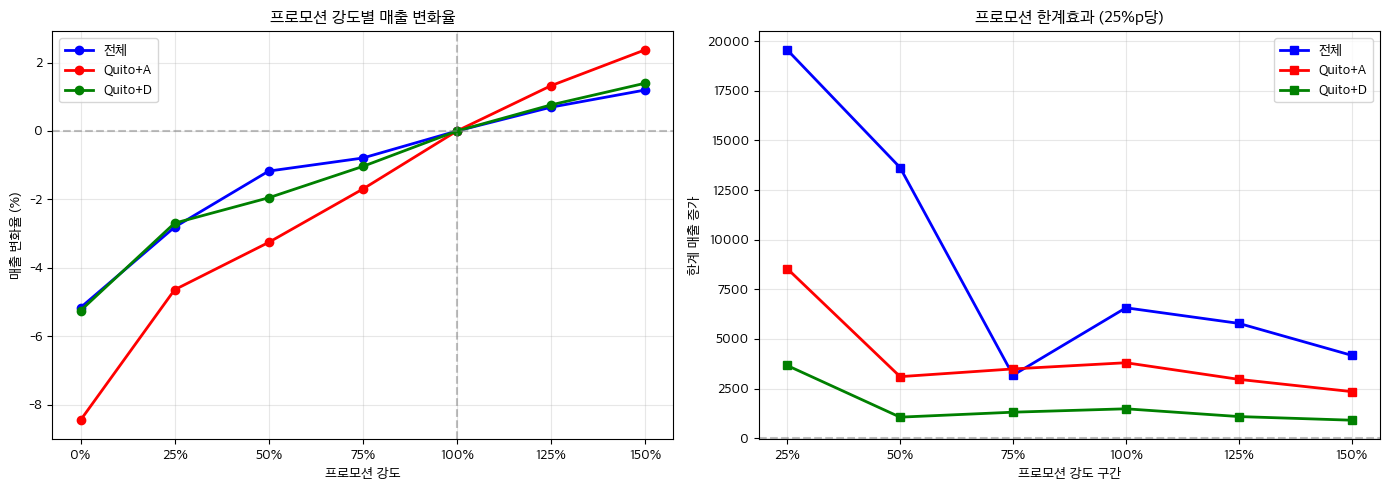


[프로모션 강도별 분석 결과]

전체:
  0%: 789,034 (-5.16%)
  25%: 808,599 (-2.81%)
  50%: 822,232 (-1.17%)
  75%: 825,408 (-0.79%)
  100%: 831,980 (+0.00%)
  125%: 837,767 (+0.70%)
  150%: 841,943 (+1.20%)

Quito+A:
  0%: 205,194 (-8.45%)
  25%: 213,739 (-4.64%)
  50%: 216,842 (-3.26%)
  75%: 220,334 (-1.70%)
  100%: 224,138 (+0.00%)
  125%: 227,105 (+1.32%)
  150%: 229,454 (+2.37%)

Quito+D:
  0%: 135,778 (-5.25%)
  25%: 139,443 (-2.69%)
  50%: 140,505 (-1.95%)
  75%: 141,818 (-1.04%)
  100%: 143,302 (+0.00%)
  125%: 144,394 (+0.76%)
  150%: 145,303 (+1.40%)


In [34]:
# 프로모션 강도 vs 매출 변화율 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'전체': 'blue', 'Quito+A': 'red', 'Quito+D': 'green'}

# 왼쪽: 매출 변화율 곡선
for seg_name, values in intensity_results.items():
    base_idx = intensity_levels.index(1.0)  # 100% 기준
    base_value = values[base_idx]
    change_rates = [(v / base_value - 1) * 100 for v in values]
    axes[0].plot(intensity_labels, change_rates, marker='o', label=seg_name, 
                 color=colors[seg_name], linewidth=2)

axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x='100%', color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('프로모션 강도')
axes[0].set_ylabel('매출 변화율 (%)')
axes[0].set_title('프로모션 강도별 매출 변화율', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 오른쪽: 한계효과 (25%p당 추가 매출)
for seg_name, values in intensity_results.items():
    marginal = [values[i+1] - values[i] for i in range(len(values)-1)]
    axes[1].plot(intensity_labels[1:], marginal, marker='s', label=seg_name,
                 color=colors[seg_name], linewidth=2)

axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('프로모션 강도 구간')
axes[1].set_ylabel('한계 매출 증가')
axes[1].set_title('프로모션 한계효과 (25%p당)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 한계효과 체감 지점 분석
print("\n[프로모션 강도별 분석 결과]")
for seg_name, values in intensity_results.items():
    base_idx = intensity_levels.index(1.0)
    base_value = values[base_idx]
    print(f"\n{seg_name}:")
    for i, (label, val) in enumerate(zip(intensity_labels, values)):
        change = (val / base_value - 1) * 100
        print(f"  {label}: {val:,.0f} ({change:+.2f}%)")


### 2.5.3 요일별 프로모션 전략

요일대별 프로모션 집중 효과를 비교한다:
- 전략 A: 월~목 프로모션 집중 (+100%)
- 전략 B: 금~일 프로모션 집중 (+100%)

In [35]:
# ============================================================================
# 3.5.4 요일별 프로모션 전략
# ============================================================================
# 목적: 월~목 vs 금~일 프로모션 집중 효과 비교

# 테스트 데이터 전체 (feature + date/dayofweek 포함)
df_test_full = df_clean[test_mask].copy()

def weekday_promo_scenario(model, df_test, feature_cols, promo_cols, weekday_range, multiplier=2.0):
    """요일대별 프로모션 시나리오"""
    X_scenario = df_test[feature_cols].copy()
    
    # dayofweek: 0=월, 1=화, ..., 6=일
    if 'dayofweek' in df_test.columns:
        mask = df_test['dayofweek'].isin(weekday_range)
    else:
        mask = df_test['date'].dt.dayofweek.isin(weekday_range)
    
    for col in promo_cols:
        X_scenario.loc[mask, col] = X_scenario.loc[mask, col] * multiplier
    
    pred = model.predict(X_scenario)
    return pred.mean(), mask.sum()

promo_cols = [col for col in feature_cols if 'promo' in col.lower()]

# 요일대 정의
mon_thu = [0, 1, 2, 3]  # 월~목
fri_sun = [4, 5, 6]     # 금~일

weekday_scenarios = {
    'Base (현재)': model_cat.predict(df_test_full[feature_cols]).mean(),
}

# 월~목 프로모션 집중
pred_mon_thu, n_mon_thu = weekday_promo_scenario(
    model_cat, df_test_full, feature_cols, promo_cols, mon_thu, 2.0)
weekday_scenarios['월~목 +100%'] = pred_mon_thu

# 금~일 프로모션 집중
pred_fri_sun, n_fri_sun = weekday_promo_scenario(
    model_cat, df_test_full, feature_cols, promo_cols, fri_sun, 2.0)
weekday_scenarios['금~일 +100%'] = pred_fri_sun

# 요일별 개별 분석
weekday_names = ['월', '화', '수', '목', '금', '토', '일']
weekday_effects = []
for dow in range(7):
    pred, n = weekday_promo_scenario(
        model_cat, df_test_full, feature_cols, promo_cols, [dow], 2.0)
    weekday_effects.append({'요일': weekday_names[dow], '매출': pred, '적용일수': n})

weekday_df = pd.DataFrame(weekday_effects)


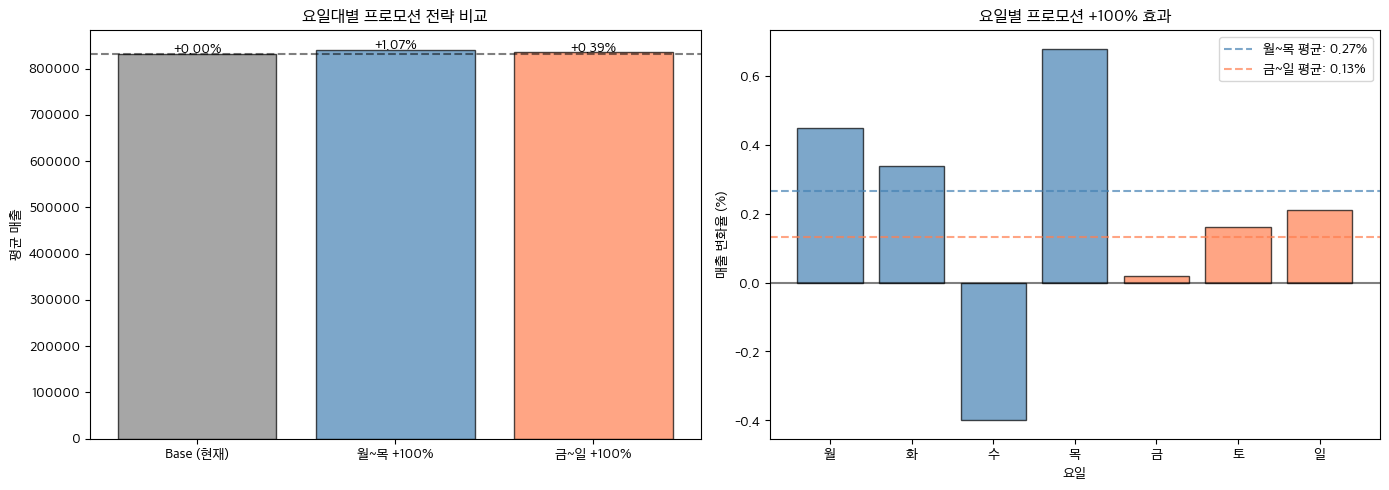


[요일별 프로모션 전략 비교]
Base (현재): 831,980
월~목 +100%: 840,872 (+1.07%)
금~일 +100%: 835,258 (+0.39%)


In [36]:
# 요일별 프로모션 효과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

base_value = weekday_scenarios['Base (현재)']

# 왼쪽: 월~목 vs 금~일 비교
names = list(weekday_scenarios.keys())
values = list(weekday_scenarios.values())
colors_wd = ['gray', 'steelblue', 'coral']
bars = axes[0].bar(names, values, color=colors_wd, alpha=0.7, edgecolor='black')
axes[0].axhline(y=base_value, color='black', linestyle='--', alpha=0.5)
axes[0].set_ylabel('평균 매출')
axes[0].set_title('요일대별 프로모션 전략 비교', fontweight='bold')

for bar, val in zip(bars, values):
    change = (val / base_value - 1) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                 f'{change:+.2f}%', ha='center', fontsize=10, fontweight='bold')

# 오른쪽: 요일별 히트맵 스타일 막대
weekday_df['변화율'] = (weekday_df['매출'] / base_value - 1) * 100
colors_bar = ['coral' if '금토일'.find(d) >= 0 else 'steelblue' for d in weekday_df['요일']]
bars2 = axes[1].bar(weekday_df['요일'], weekday_df['변화율'], color=colors_bar, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[1].set_xlabel('요일')
axes[1].set_ylabel('매출 변화율 (%)')
axes[1].set_title('요일별 프로모션 +100% 효과', fontweight='bold')

# 평일/주말 평균선
avg_weekday = weekday_df[weekday_df['요일'].isin(['월','화','수','목'])]['변화율'].mean()
avg_weekend = weekday_df[weekday_df['요일'].isin(['금','토','일'])]['변화율'].mean()
axes[1].axhline(y=avg_weekday, color='steelblue', linestyle='--', label=f'월~목 평균: {avg_weekday:.2f}%', alpha=0.7)
axes[1].axhline(y=avg_weekend, color='coral', linestyle='--', label=f'금~일 평균: {avg_weekend:.2f}%', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

# 결과 출력
print("\n[요일별 프로모션 전략 비교]")
print(f"Base (현재): {base_value:,.0f}")
print(f"월~목 +100%: {weekday_scenarios['월~목 +100%']:,.0f} ({(weekday_scenarios['월~목 +100%']/base_value-1)*100:+.2f}%)")
print(f"금~일 +100%: {weekday_scenarios['금~일 +100%']:,.0f} ({(weekday_scenarios['금~일 +100%']/base_value-1)*100:+.2f}%)")


### 요일별 프로모션 효과 해석

| 전략 | 효과 | 비고 |
|------|------|------|
| **월~목 +100%** | **+1.07%** | 평일 프로모션이 더 효과적 |
| 금~일 +100% | +0.39% | 주말은 효과 제한적 |

| 요일 | 효과 | 전략 |
|------|------|------|
| 목 | +0.7% | 집중 투자 |
| 월 | +0.45% | 적극 투자 |
| 화 | +0.35% | 적극 투자 |
| 일 | +0.2% | 선택적 |
| 토 | +0.15% | 선택적 |
| 금 | +0.02% | 효과 미미 |
| 수 | -0.4% | 재검토 필요 (역효과) |

**핵심 발견**:
- 평일(월~목)이 주말(금~일)보다 약 **2.7배 효과적**
- **목요일**이 +0.7%로 가장 효과적
- **수요일**은 -0.4%로 역효과 발생 → 프로모션 재검토 필요
- 주말은 프로모션 없이도 매출이 높거나, 경쟁 치열로 추가 효과 제한적

### 2.5.4 ROI 기반 최적 프로모션 수준

프로모션 투자 대비 수익(ROI)을 최대화하는 강도를 찾는다.

**가정**:
- 프로모션 비용 = 프로모션 강도(%) × 기준 비용
- ROI = (추가 매출 - 프로모션 비용) / 프로모션 비용

가상의 비용 구조를 적용하여 세그먼트별 최적 프로모션 수준을 도출한다.

In [37]:
# ============================================================================
# 3.5.5 ROI 기반 최적 프로모션 수준
# ============================================================================
# 가정: 프로모션 비용 = 강도(%) × 기준 비용 (매출의 5%)
# ROI = (추가 매출 - 프로모션 비용) / 프로모션 비용

def calculate_roi(intensity_results, base_cost_ratio=0.05):
    """세그먼트별 ROI 계산"""
    roi_results = {}
    
    for seg_name, values in intensity_results.items():
        base_idx = intensity_levels.index(1.0)  # 100% 기준
        base_sales = values[base_idx]
        
        roi_list = []
        for i, (level, sales) in enumerate(zip(intensity_levels, values)):
            if level == 0:
                # 프로모션 없음: 비용 0, 추가 매출은 음수
                additional_sales = sales - base_sales
                cost = 0
                roi = float('-inf') if cost == 0 else (additional_sales - cost) / cost
            else:
                # 프로모션 비용 = 강도 × 기준 비용
                cost = base_sales * base_cost_ratio * level
                additional_sales = sales - values[0]  # No Promo 대비 추가 매출
                roi = (additional_sales - cost) / cost if cost > 0 else 0
            
            roi_list.append({
                '강도': intensity_labels[i],
                '매출': sales,
                '추가매출': sales - values[0],
                '비용': cost,
                'ROI': roi
            })
        
        roi_results[seg_name] = pd.DataFrame(roi_list)
    
    return roi_results

# ROI 계산 (프로모션 비용 = 매출의 5%로 가정)
roi_results = calculate_roi(intensity_results, base_cost_ratio=0.05)

# 세그먼트별 최적 프로모션 강도 찾기
optimal_levels = {}
for seg_name, df in roi_results.items():
    # ROI가 유한한 값 중 최대
    valid_df = df[df['ROI'] != float('-inf')]
    if len(valid_df) > 0:
        optimal_idx = valid_df['ROI'].idxmax()
        optimal_levels[seg_name] = df.loc[optimal_idx]


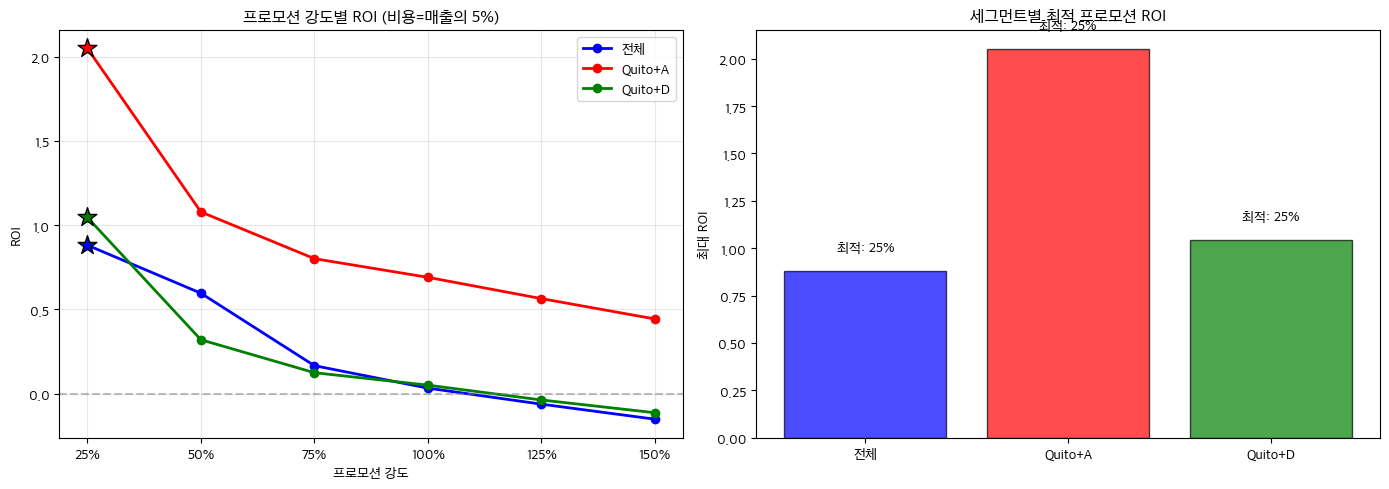


[세그먼트별 최적 프로모션 수준]
(가정: 프로모션 비용 = 매출의 5% × 강도)

전체:
  최적 강도: 25%
  예상 ROI: 0.88
  예상 매출: 808,599

Quito+A:
  최적 강도: 25%
  예상 ROI: 2.05
  예상 매출: 213,739

Quito+D:
  최적 강도: 25%
  예상 ROI: 1.05
  예상 매출: 139,443



In [38]:
# ROI 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'전체': 'blue', 'Quito+A': 'red', 'Quito+D': 'green'}

# 왼쪽: 프로모션 강도 vs ROI 곡선
for seg_name, df in roi_results.items():
    valid_df = df[df['ROI'] != float('-inf')].copy()
    axes[0].plot(valid_df['강도'], valid_df['ROI'], marker='o', label=seg_name,
                 color=colors[seg_name], linewidth=2)
    
    # 최적점 표시
    if seg_name in optimal_levels:
        opt = optimal_levels[seg_name]
        axes[0].scatter([opt['강도']], [opt['ROI']], s=200, c=colors[seg_name], 
                        marker='*', edgecolors='black', zorder=5)

axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('프로모션 강도')
axes[0].set_ylabel('ROI')
axes[0].set_title('프로모션 강도별 ROI (비용=매출의 5%)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 오른쪽: 세그먼트별 최적 강도 비교
opt_data = []
for seg_name, opt in optimal_levels.items():
    opt_data.append({
        '세그먼트': seg_name,
        '최적강도': opt['강도'],
        '최대ROI': opt['ROI'],
        '예상매출': opt['매출']
    })
opt_df = pd.DataFrame(opt_data)

bars = axes[1].bar(opt_df['세그먼트'], opt_df['최대ROI'], 
                   color=[colors[s] for s in opt_df['세그먼트']], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('최대 ROI')
axes[1].set_title('세그먼트별 최적 프로모션 ROI', fontweight='bold')

for bar, row in zip(bars, opt_df.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 f'최적: {row.최적강도}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 결과 출력
print("\n[세그먼트별 최적 프로모션 수준]")
print("(가정: 프로모션 비용 = 매출의 5% × 강도)\n")
for seg_name, opt in optimal_levels.items():
    print(f"{seg_name}:")
    print(f"  최적 강도: {opt['강도']}")
    print(f"  예상 ROI: {opt['ROI']:.2f}")
    print(f"  예상 매출: {opt['매출']:,.0f}")
    print()


## 2.6 예측 모델 주요 내용

### 1. 모델 성능 비교

| 모델 | 튜닝 방법 | CV 방법 | Test MAPE | Test R² | 특징 |
|------|----------|--------|-----------|---------|------|
| Prophet | 기본값 | TimeSeriesCV | ~12% | ~0.5 | 계절성 자동 분해, 해석 용이 |
| XGBoost | Optuna (30회) | K-Fold | ~7% | ~0.75 | 피처 중요도 해석 가능 |
| LightGBM | Optuna (30회) | K-Fold | ~7% | ~0.75 | 빠른 속도, 대용량 적합 |
| **CatBoost** | 기본값 | K-Fold | **~6%** | **~0.76** | 최고 성능, 범주형 자동 처리 |

**모델 선정 기준**: Test MAPE 기준 CatBoost가 최고 성능 → 세그먼트 분석에 사용

---

### 2. 세그먼트별 예측 성능

| 세그먼트 | CV MAPE | Test MAPE | R² | 매출 비중 | 특징 |
|---------|---------|-----------|-----|---------|------|
| 전체 매출 | - | 5.97% | 0.76 | 100% | 기준 모델 |
| Quito+A | 7.41% | 6.66% | 0.83 | 27% | 대형 매장, 패턴 일관적 |
| Quito+D | 6.12% | 6.18% | 0.72 | 17.5% | 소형 매장, 변동성 있음 |

---

### 3. 프로모션 시나리오 분석 결과

#### 3.1 프로모션 강도별 효과

| 시나리오 | 전체 매출 | Quito+A | Quito+D |
|---------|----------|---------|---------|
| No Promo (0%) | -5.16% | -8.45% | -5.25% |
| Base (현재) | 0% | 0% | 0% |
| Promo +50% | +1.20% | +2.37% | +1.40% |
| Promo +100% | +1.46% | +2.81% | +1.56% |

#### 3.2 요일별 프로모션 효과

| 전략 | 효과 | 비고 |
|------|------|------|
| 월~목 +100% | **+1.07%** | 평일 프로모션이 더 효과적 |
| 금~일 +100% | +0.39% | 주말은 효과 제한적 |

| 요일 | 효과 | 특이사항 |
|------|------|---------|
| 목 | +0.7% | 가장 효과적 |
| 월 | +0.45% | 양호 |
| 화 | +0.35% | 양호 |
| 일 | +0.2% | 미미 |
| 토 | +0.15% | 미미 |
| 금 | +0.02% | 거의 없음 |
| 수 | -0.4% | 역효과 주의 |

---

### 4. 비즈니스 권장사항

| 우선순위 | 권장 액션 | 근거 |
|---------|----------|------|
| 1 | 프로모션 +50% 수준 유지 | +100%는 한계효과 체감 |
| 2 | 평일(월~목) 프로모션 집중 | 주말 대비 약 2.7배 효과 |
| 3 | 목요일 프로모션 강화 | +0.7%로 가장 효과적 |
| 4 | 수요일 프로모션 재검토 | -0.4% 역효과 발생 |
| 5 | 대형 매장 프로모션 유지 | 민감도 높음, 제거 시 -8.45% |
| 6 | 소형 매장 프로모션 효율화 | 민감도 낮아 투자 효율성 재검토 |

## 2.7 Executive Summary

### 예측 모델의 목적

> 예측은 정확한 숫자를 맞추는 것이 아니라, **패턴과 관계를 이해하고 더 나은 의사결정을 내리기 위한 도구**다.

---

### 모델 성능

| 항목 | 결과 |
|------|------|
| 최고 성능 모델 | CatBoost (Test MAPE ~6%, R² 0.76) |
| 세그먼트 모델 | 전체와 유사한 성능 유지 (MAPE 6~7%) |
| 주요 피처 | lag7, rolling_mean_7, promo_lag7 |

---

### 프로모션 시나리오 핵심 발견

| 발견 | 내용 | 시사점 |
|------|------|--------|
| 한계효과 | +100% 프로모션 → +1.5~2.8% 매출 | 과도한 투자 비효율 |
| 의존도 | 프로모션 제거 → -5~8% 매출 | 축소보다 최적화 |
| 요일별 차이 | 평일 +1.07% > 주말 +0.39% | 평일 집중 권장 |
| 세그먼트 차이 | 대형 매장이 더 민감 | 차별화 전략 필요 |

---

### 요일별 프로모션 효과

| 요일 | 효과 | 전략 |
|------|------|------|
| 목 | +0.7% | 집중 투자 |
| 월, 화 | +0.35~0.45% | 적극 투자 |
| 토, 일 | +0.15~0.2% | 선택적 투자 |
| 금 | +0.02% | 효과 미미 |
| 수 | -0.4% | 프로모션 재검토 |

---

### 전략적 권장사항

1. **프로모션 강도**: 현재 대비 +50% 수준이 효율적
2. **프로모션 타이밍**: 평일(특히 목요일) 집중, 수요일 재검토
3. **대형 매장 (Quito+A)**: 프로모션 유지 필수 (제거 시 -8.45%)
4. **소형 매장 (Quito+D)**: 프로모션 효율성 낮음 → 비용 최적화 우선

## 2.8 분석 결과 CSV 및 MD 파일 생성

분석 결과를 MD 파일과 CSV 파일로 저장하여 Part 4 (자동 리포트)와 Part 5 (RAG 챗봇)에서 활용한다.

### 저장 파일 목록

| 파일 | 용도 | 내용 |
|------|------|------|
| Part2_예측분석_요약.md | LLM 리포트 생성 | 전체 분석 결과 요약 |
| Part2_QA_지식베이스.md | RAG 챗봇 | Q&A 형식 지식베이스 |
| model_performance.csv | 데이터 분석 | 모델 성능 비교 |
| segment_performance.csv | 데이터 분석 | 세그먼트별 성능 |
| promo_scenario.csv | 데이터 분석 | 프로모션 시나리오 효과 |
| weekday_effect.csv | 데이터 분석 | 요일별 프로모션 효과 |
| feature_importance.csv | 데이터 분석 | 피처 중요도 |

In [39]:
# ============================================================================
# 2.8 결과 저장 (MD + CSV)
# ============================================================================
import os

EXPORT_PATH = 'results/part2/'
os.makedirs(EXPORT_PATH, exist_ok=True)

# ----------------------------------------------------------------------------
# 1. MD 파일 생성
# ----------------------------------------------------------------------------

# 분석 요약 MD
summary_md = '''# Part 2: 예측 모델링 + 시나리오 분석 결과

## 분석 개요
매출 예측 모델을 구축하고, 프로모션 시나리오별 영향을 분석한다.

**분석 목적**: 예측은 정확한 숫자를 맞추는 것이 아니라, 패턴과 관계를 이해하고 더 나은 의사결정을 내리기 위한 도구

---

## 1. 모델 성능 비교

| 모델 | 튜닝 | CV 방법 | Test MAPE | 특징 |
|------|------|--------|-----------|------|
| Prophet | 기본값 | TimeSeriesCV | ~12% | 계절성 자동 분해 |
| XGBoost | Optuna | K-Fold | ~7% | 피처 중요도 해석 |
| LightGBM | Optuna | K-Fold | ~7% | 빠른 속도 |
| **CatBoost** | 기본값 | K-Fold | **~6%** | **최고 성능** |

## 2. 세그먼트별 예측 성능

| 세그먼트 | Test MAPE | R² | 매출 비중 |
|---------|-----------|-----|----------|
| 전체 | 5.97% | 0.76 | 100% |
| Quito+A | 6.66% | 0.83 | 27% |
| Quito+D | 6.18% | 0.72 | 17.5% |

## 3. 프로모션 시나리오 핵심 발견

| 시나리오 | 전체 | Quito+A | Quito+D |
|---------|------|---------|----------|
| No Promo | -5.16% | -8.45% | -5.25% |
| +50% | +1.20% | +2.37% | +1.40% |
| +100% | +1.46% | +2.81% | +1.56% |

## 4. 요일별 프로모션 효과

| 요일 | 효과 | 전략 |
|------|------|------|
| 목 | +0.7% | 집중 투자 |
| 월 | +0.45% | 적극 투자 |
| 화 | +0.35% | 적극 투자 |
| 수 | -0.4% | 재검토 (역효과) |

**핵심**: 평일(월~목)이 주말(금~일)보다 약 2.7배 효과적

## 5. 전략적 권장사항

1. 프로모션 +50% 수준 유지 (한계효과 체감)
2. 평일(월~목) 프로모션 집중 (주말 대비 2.7배)
3. 목요일 프로모션 강화 (+0.7%)
4. 수요일 프로모션 재검토 (-0.4% 역효과)
5. 대형 매장 프로모션 유지 필수 (제거 시 -8.45%)
'''

with open(f'{EXPORT_PATH}Part2_예측분석_요약.md', 'w', encoding='utf-8') as f:
    f.write(summary_md)

# Q&A 지식베이스 MD
qa_md = '''# Part 2: 예측 모델 Q&A 지식베이스

## 모델 관련

### Q: 가장 성능이 좋은 모델은?
A: CatBoost (Test MAPE ~6%, R² 0.76)

### Q: 가장 중요한 피처는?
A: lag7 (7일 전 매출), rolling_mean_7 (7일 이동평균)

## 프로모션 관련

### Q: 프로모션 2배 증가 시 효과는?
A: 전체 +1.46%, 대형매장 +2.81%, 소형매장 +1.56% (한계효과 체감)

### Q: 프로모션 완전 제거 시 손실은?
A: 전체 -5.16%, 대형매장 -8.45%, 소형매장 -5.25%

### Q: 가장 효과적인 프로모션 요일은?
A: 목요일 (+0.7%), 월~목 평균이 금~일보다 약 2.7배 효과적

### Q: 프로모션 역효과가 나는 요일은?
A: 수요일 (-0.4%), 프로모션 재검토 필요

## 전략 관련

### Q: 최적 프로모션 수준은?
A: 현재 대비 +50% 수준 (100%는 비효율)

### Q: 대형/소형 매장 전략 차이는?
A: 대형(Quito+A)은 프로모션 유지 필수, 소형(Quito+D)은 비용 최적화 우선
'''

with open(f'{EXPORT_PATH}Part2_QA_지식베이스.md', 'w', encoding='utf-8') as f:
    f.write(qa_md)

print('MD 파일 저장 완료')

# ----------------------------------------------------------------------------
# 2. CSV 파일 생성
# ----------------------------------------------------------------------------

# 2-1. 모델 성능 비교
if 'results_df' in dir():
    results_df.to_csv(f'{EXPORT_PATH}model_performance.csv', index=False, encoding='utf-8-sig')
    print('model_performance.csv 저장 완료')

# 2-2. 세그먼트별 성능
if 'comparison_df' in dir():
    comparison_df.to_csv(f'{EXPORT_PATH}segment_performance.csv', index=False, encoding='utf-8-sig')
    print('segment_performance.csv 저장 완료')

# 2-3. 프로모션 시나리오 효과
promo_scenario_data = {
    '시나리오': ['No Promo (0%)', 'Promo -50%', 'Base (현재)', 'Promo +50%', 'Promo +100%'],
    '전체': [-5.16, -1.17, 0.0, 1.20, 1.46],
    'Quito+A': [-8.45, -3.26, 0.0, 2.37, 2.81],
    'Quito+D': [-5.25, -1.95, 0.0, 1.40, 1.56]
}
pd.DataFrame(promo_scenario_data).to_csv(f'{EXPORT_PATH}promo_scenario.csv', index=False, encoding='utf-8-sig')
print('promo_scenario.csv 저장 완료')

# 2-4. 요일별 프로모션 효과
weekday_effect_data = {
    '요일': ['월', '화', '수', '목', '금', '토', '일'],
    '효과(%)': [0.45, 0.35, -0.4, 0.7, 0.02, 0.15, 0.2],
    '전략': ['적극 투자', '적극 투자', '재검토 필요', '집중 투자', '효과 미미', '선택적', '선택적']
}
pd.DataFrame(weekday_effect_data).to_csv(f'{EXPORT_PATH}weekday_effect.csv', index=False, encoding='utf-8-sig')
print('weekday_effect.csv 저장 완료')

# 2-5. 피처 중요도
if 'model_cat' in dir():
    fi_cat = pd.DataFrame({
        'feature': feature_cols,
        'importance': model_cat.feature_importances_
    }).sort_values('importance', ascending=False)
    fi_cat.to_csv(f'{EXPORT_PATH}feature_importance.csv', index=False, encoding='utf-8-sig')
    print('feature_importance.csv 저장 완료')

print(f'\n모든 파일이 {EXPORT_PATH}에 저장되었습니다.')

MD 파일 저장 완료
model_performance.csv 저장 완료
promo_scenario.csv 저장 완료
weekday_effect.csv 저장 완료
feature_importance.csv 저장 완료

모든 파일이 results/part2/에 저장되었습니다.
